## Medical Insurance Prediction

Predicting annual medical costs (regression).

### Data Preparation

Read medical_insurance.csv, and print info and description of columns.

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [ ]:
# Mount Google Drive
from google.colab import drive

# permission to access my Google Drive
drive.mount('/content/drive')
# reading medical_insurance.csv
df=pd.read_csv('/content/drive/MyDrive/DSAI_5102/project/medical_insurance.csv')

Mounted at /content/drive


### Check data structure

In [ ]:
df.head()

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,...,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
0,75722,52,Female,North,Suburban,22700.0,Doctorate,Married,Retired,3,...,0,1,0,1,0,2,0,1,0,0
1,80185,79,Female,North,Urban,12800.0,No HS,Married,Employed,3,...,0,1,1,0,0,1,0,1,1,0
2,19865,68,Male,North,Rural,40700.0,HS,Married,Retired,5,...,0,0,1,1,0,2,1,0,1,0
3,76700,15,Male,North,Suburban,15600.0,Some College,Married,Self-employed,5,...,0,0,0,1,0,0,1,0,0,0
4,92992,53,Male,Central,Suburban,89600.0,Doctorate,Married,Self-employed,2,...,0,1,0,2,0,1,1,0,1,0


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 100000 entries, 0 to 99999
Data columns (total 54 columns):
 #   Column                       Non-Null Count   Dtype  
---  ------                       --------------   -----  
 0   person_id                    100000 non-null  int64  
 1   age                          100000 non-null  int64  
 2   sex                          100000 non-null  object 
 3   region                       100000 non-null  object 
 4   urban_rural                  100000 non-null  object 
 5   income                       100000 non-null  float64
 6   education                    100000 non-null  object 
 7   marital_status               100000 non-null  object 
 8   employment_status            100000 non-null  object 
 9   household_size               100000 non-null  int64  
 10  dependents                   100000 non-null  int64  
 11  bmi                          100000 non-null  float64
 12  smoker                       100000 non-null  object 
 13  

The dataset contains 54 columns and 100,000 complete entries, with missing values in cloumn alcohol_freq.

Additional, the features are categorical(object) or numerical type(int64 or float64).

In [ ]:
pd.set_option('display.max_columns', None)  # None: 不限制列数
pd.set_option('display.max_rows', None)     # None: 不限制行数
pd.set_option('display.width', 1000)       # 增加显示宽度，避免折叠

In [ ]:
df.describe(include='all')

,person_id,age,sex,region,urban_rural,income,education,marital_status,employment_status,household_size,dependents,bmi,smoker,alcohol_freq,visits_last_year,hospitalizations_last_3yrs,days_hospitalized_last_3yrs,medication_count,systolic_bp,diastolic_bp,ldl,hba1c,plan_type,network_tier,deductible,copay,policy_term_years,policy_changes_last_2yrs,provider_quality,risk_score,annual_medical_cost,annual_premium,monthly_premium,claims_count,avg_claim_amount,total_claims_paid,chronic_count,hypertension,diabetes,asthma,copd,cardiovascular_disease,cancer_history,kidney_disease,liver_disease,arthritis,mental_health,proc_imaging_count,proc_surgery_count,proc_physio_count,proc_consult_count,proc_lab_count,is_high_risk,had_major_procedure
count,100000.000000,100000.000000,100000,100000,100000,1.000000e+05,100000,100000,100000,100000.000000,100000.000000,100000.000000,100000,69917,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000,100000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.000000,100000.00000,100000.000000,100000.000000,100000.000000
unique,NaN,NaN,3,5,3,NaN,6,4,4,NaN,NaN,NaN,3,3,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,4,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
top,NaN,NaN,Female,South,Urban,NaN,Bachelors,Married,Employed,NaN,NaN,NaN,Never,Occasional,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,PPO,Silver,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
freq,NaN,NaN,49193,28029,60019,NaN,27996,53252,55269,NaN,NaN,NaN,69709,45078,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,35167,40177,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN
mean,50000.500000,47.521500,NaN,NaN,NaN,4.987390e+04,NaN,NaN,NaN,2.430900,0.898380,26.990512,NaN,NaN,1.92765,0.093640,0.373350,1.236320,117.808970,73.604770,119.975065,5.605968,NaN,NaN,1226.725000,19.520400,5.517760,0.050690,3.598920,0.519849,3009.451907,582.320040,48.526668,1.62178,656.512084,1377.878827,0.724720,0.203450,0.085930,0.058870,0.035950,0.051170,0.021510,0.014620,0.014770,0.108310,0.130140,0.508530,0.158690,0.508390,0.50933,0.509140,0.367810,0.169700
std,28867.657797,15.988752,NaN,NaN,NaN,4.680021e+04,NaN,NaN,NaN,1.075126,0.950654,4.994883,NaN,NaN,1.73773,0.304848,1.373011,1.209358,15.369187,8.900924,30.262086,0.845996,NaN,NaN,1019.619375,10.286255,2.868827,0.224591,0.594052,0.250669,3127.462822,399.583722,33.298640,2.02982,1072.660048,2305.464687,0.805523,0.402566,0.280262,0.235382,0.186166,0.220345,0.145078,0.120027,0.120632,0.310773,0.336459,0.749755,0.463562,0.747218,0.75363,0.750455,0.482212,0.375371
min,1.000000,0.000000,NaN,NaN,NaN,1.100000e+03,NaN,NaN,NaN,1.000000,0.000000,12.000000,NaN,NaN,0.00000,0.000000,0.000000,0.000000,61.000000,40.000000,30.000000,3.540000,NaN,NaN,500.000000,10.000000,1.000000,0.000000,1.500000,0.000000,55.550000,211.670000,17.640000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
25%,25000.750000,37.000000,NaN,NaN,NaN,2.110000e+04,NaN,NaN,NaN,2.000000,0.000000,23.600000,NaN,NaN,1.00000,0.000000,0.000000,0.000000,107.000000,67.000000,99.400000,5.160000,NaN,NaN,500.000000,10.000000,3.000000,0.000000,3.200000,0.329700,1175.117500,352.070000,29.340000,0.00000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.00000,0.000000,0.000000,0.000000
50%,50000.500000,48.000000,NaN,NaN,Na

According to the statistical information, no significant outliers were detected.

Then, the null value should be handled.

In [ ]:
missing = df.isnull().sum()
print("Missing Values:")
print(missing[missing > 0] if missing.sum() > 0 else "No missing values") # print the column name and number of null value

Missing Values:
alcohol_freq    30083
dtype: int64


Only the alcohol_freq column contained 30,083 missing values. The distribution of all non-missing values in this column is shown in the figure below.

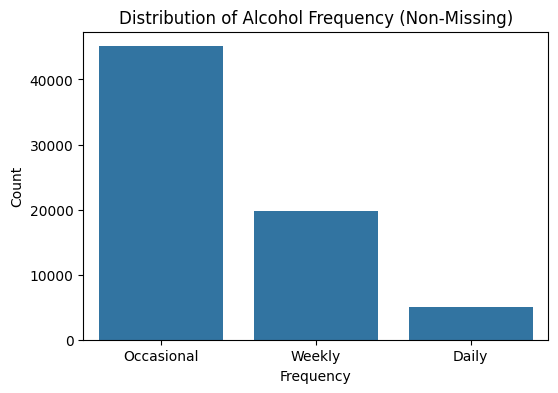

In [ ]:
plt.figure(figsize=(6, 4))

sns.countplot(
    x=df['alcohol_freq'].dropna(),
    order=df['alcohol_freq'].value_counts().index
)

plt.title('Distribution of Alcohol Frequency (Non-Missing)')
plt.xlabel('Frequency')
plt.ylabel('Count')
plt.show()

The number of 'Occasional' among non-missing data far exceeds the other two types ('weekly', 'daily'), so we decided to use the mode value 'Occasional' to handle missing values.

In [ ]:
# obtain the mode value
alcohol_mode = df['alcohol_freq'].mode()[0]

# handle the missing values
df['alcohol_freq'].fillna(alcohol_mode, inplace=True)

print(df['alcohol_freq'].isnull().sum())

0


/tmp/ipython-input-236537839.py:5: FutureWarning: A value is trying to be set on a copy of a DataFrame or Series through chained assignment using an inplace method.
The behavior will change in pandas 3.0. This inplace method will never work because the intermediate object on which we are setting values always behaves as a copy.

For example, when doing 'df[col].method(value, inplace=True)', try using 'df.method({col: value}, inplace=True)' or df[col] = df[col].method(value) instead, to perform the operation inplace on the original object.


  df['alcohol_freq'].fillna(alcohol_mode, inplace=True)


### Exploratory Data Analysis

**Check outliers**

First, according to the type of columns, dividing them into below groups.

1. Demographics & Socioeconomic: person_id, age, sex, region, urban_rural, income, education, marital_status, employment_status, household_size, dependents

2. Lifestyle & Habits: bmi, smoker, alcohol_freq

3. Health & Clinical: hypertension, diabetes, copd, cardiovascular, cancer_history, kidney_disease, liver_disease, arthritis, mental_health, chronic_count, systolic_bp, diastolic_bp, ldl, hba1c, risk_score, is_high_risk

4. Healthcare Utilization & Procedures: visits_last_year, hospitalizations_last_3yrs, days_hospitalized_last_3yrs, medication_count, proc_imaging, proc_surgery, proc_psycho, proc_consult_count, proc_lab, had_major

5. Insurance & Policy: plan_type, network_tier, deductible, copay, policy_term_years, policy_changes_last_2yrs, provider_quality

6. Medical Costs & Claims: annual_medical_cost, annual_premium, monthly_premium, claims_count, avg_claim_amount, total_claims_paid

In [ ]:
# Demographics and Socioeconomic: 10
demo = ['age', 'income', 'household_size', 'dependents',
        'sex', 'region', 'urban_rural', 'education', 'marital_status',
        'employment_status']

# Lifestyle and Habits: 3
life = ['bmi', 'smoker', 'alcohol_freq']

# Health and Clinical: 17
clinical = ['ldl', 'hba1c', 'risk_score', 'systolic_bp', 'diastolic_bp', 'chronic_count',
            'hypertension', 'diabetes', 'asthma', 'copd', 'cardiovascular_disease',
            'cancer_history', 'kidney_disease', 'liver_disease', 'arthritis',
            'mental_health', 'is_high_risk']

# Healthcare Utilization and Procedures: 10
healthcare = ['visits_last_year', 'hospitalizations_last_3yrs', 'days_hospitalized_last_3yrs',
              'medication_count', 'proc_imaging_count', 'proc_surgery_count', 'proc_physio_count',
              'proc_consult_count', 'proc_lab_count', 'had_major_procedure']

# Insurance and Policy: 7
insurance = ['deductible', 'copay', 'policy_term_years', 'policy_changes_last_2yrs',
             'provider_quality', 'plan_type', 'network_tier']

# Medical Costs and Claims: 6
cost = ['annual_medical_cost', 'annual_premium', 'monthly_premium', 'claims_count',
        'avg_claim_amount', 'total_claims_paid']

Plot different types of features.

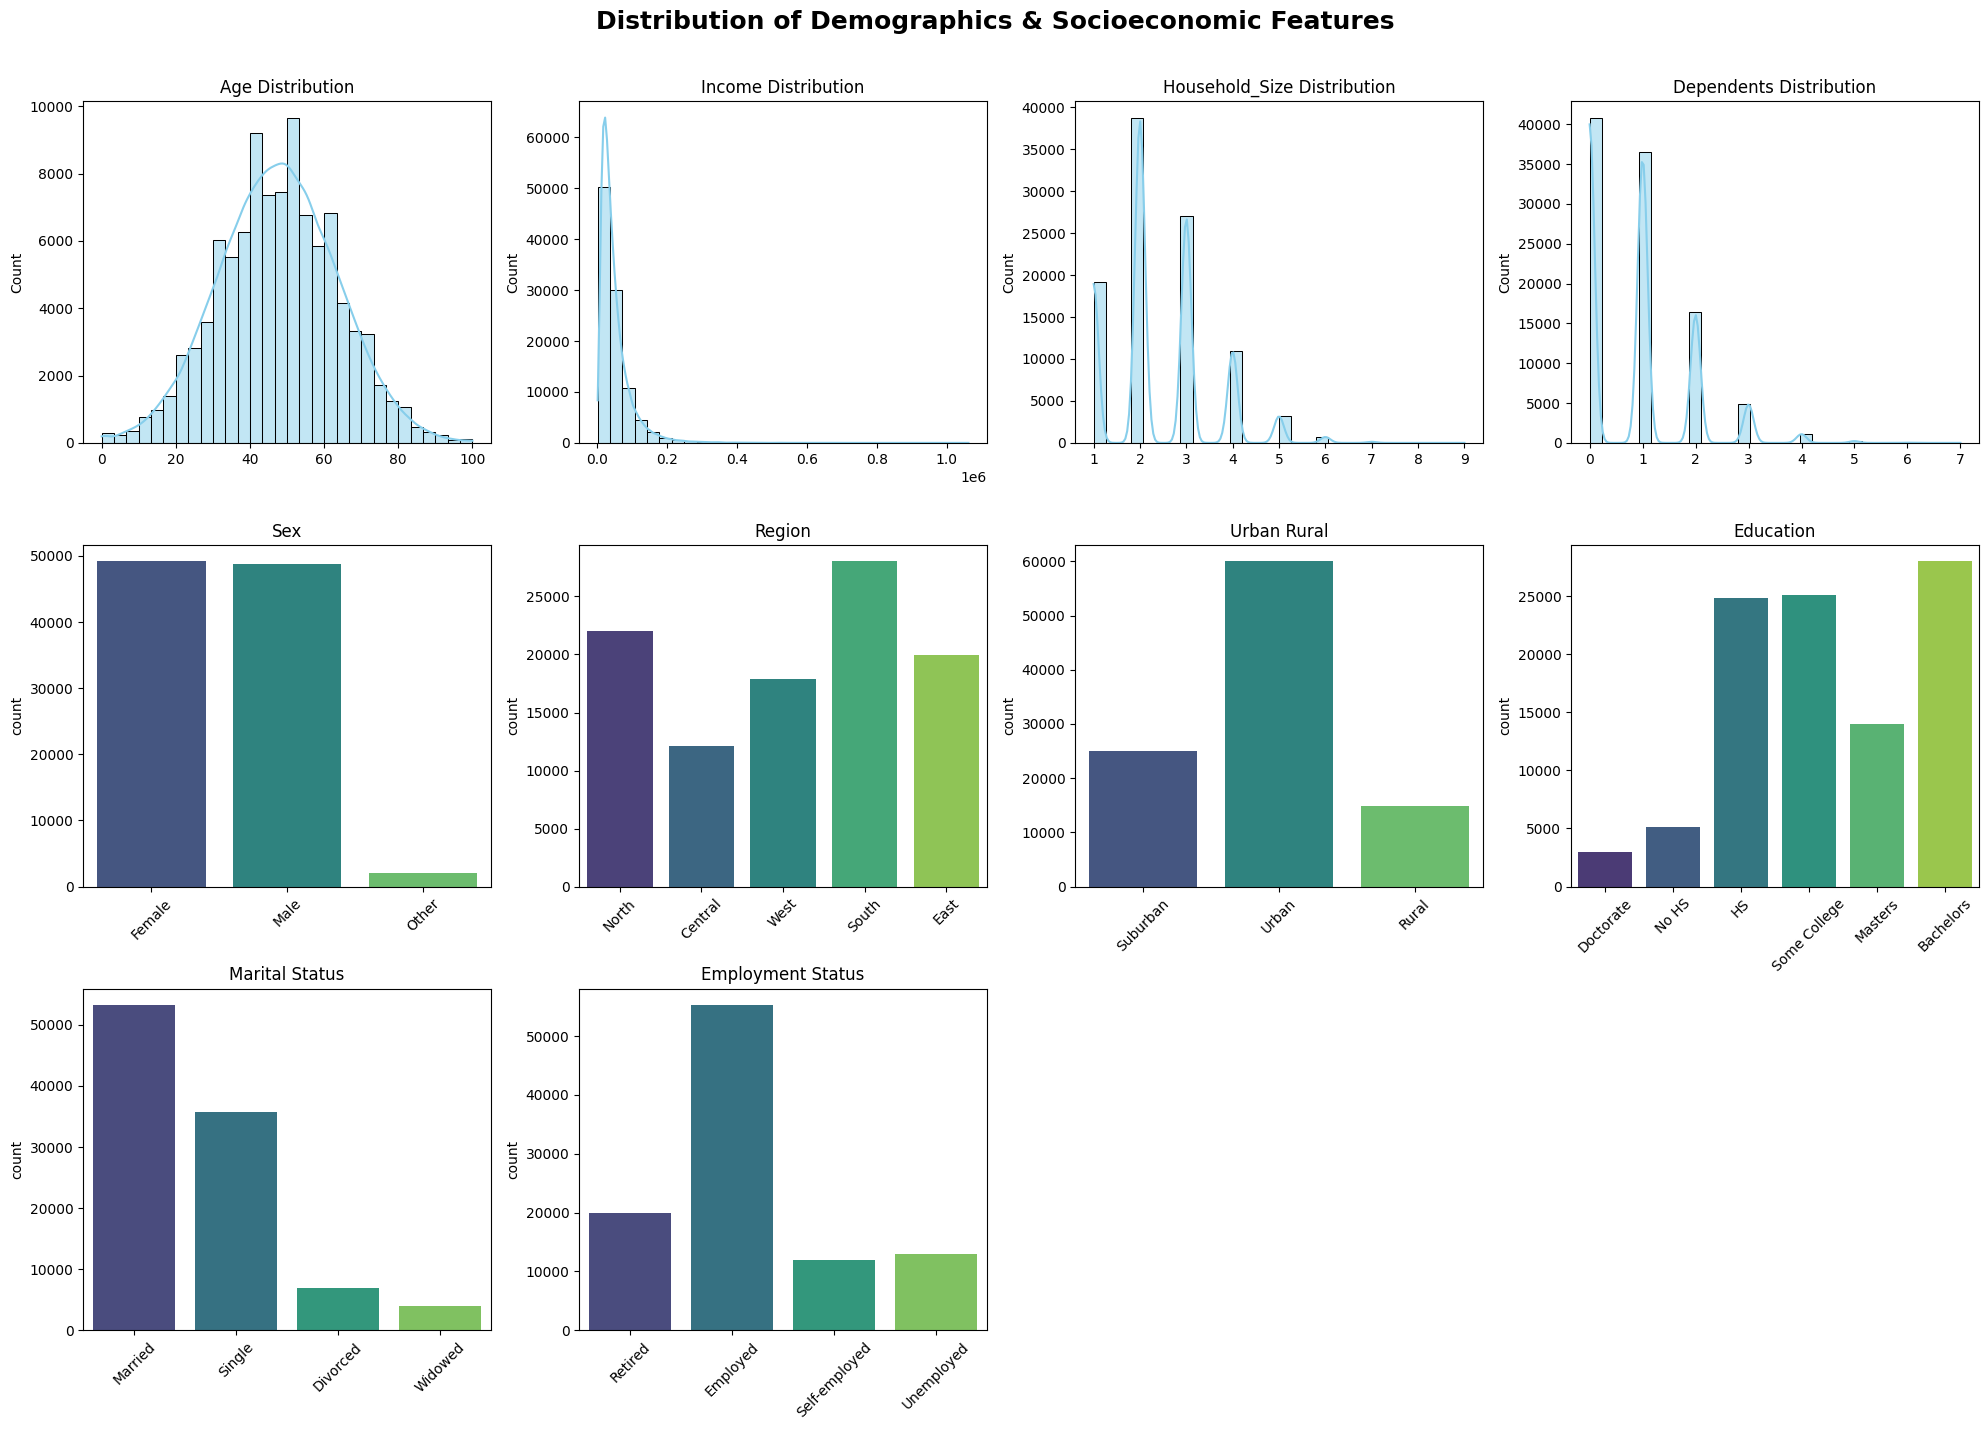

In [ ]:
# Demographics & Socioeconomic
# num: age, income, household_size, dependents
# cate: sex, region, urban_rural, education, marital_status, employment_status
demo_plots = len(demo)
demo_cols = 4 # each row has four subplots
demo_rows = int(np.ceil(demo_plots / demo_cols))

fig, axes = plt.subplots(demo_rows, demo_cols, figsize=(20, demo_rows * 5))
fig.suptitle('Distribution of Demographics & Socioeconomic Features', fontsize=18, fontweight='bold')

axes = axes.flatten()

for i, col in enumerate(demo):
    ax = axes[i]

    # numerical column
    if col in ['age', 'income', 'household_size', 'dependents']:
      sns.histplot(df[col].dropna(), kde=True, ax=ax, bins=30, color='skyblue')
      ax.set_title(f'{col.title()} Distribution')
      ax.set_xlabel('')

    # categorical/binary column
    else:
      sns.countplot(x=col, data=df, ax=ax, palette='viridis', hue=col, legend=False)
      ax.set_title(f'{col.replace("_", " ").title()}')
      ax.set_xlabel('')

      ax.tick_params(axis='x', rotation=45) # reverse the xlabel 45 rotations

# hide subplots with no data
for i in range(len(demo), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

**Demographics & Socioeconomic**

1. The values of feature 'age' show a normal distribution, covering a wide range.

2. The income Distribution is highly skewed to the right (positively skewed),
indicating that most customers fall into the lower income brackets.
And the distribution of household size proves the same conclusion from income.

3. In the dependents distribution, it is clear that the number of dependents for most customers is from 0 to 4.

4. The customer base is almost equally split between Female and Male.

5. For Region, the West and South regions appear to have slightly higher representation compared to the North and Central regions.

6. A majority of the customers reside in Urban areas, followed by Suburban areas, while the count for Rural residents is significantly lower.
This suggests the data might be biased towards city dwellers.

7. The most common Education level is Bachelors.

8. The majority of policyholders are Married.

9. Most customers are either Retired or Employed, with a smaller portion being self-employed or unemployed.

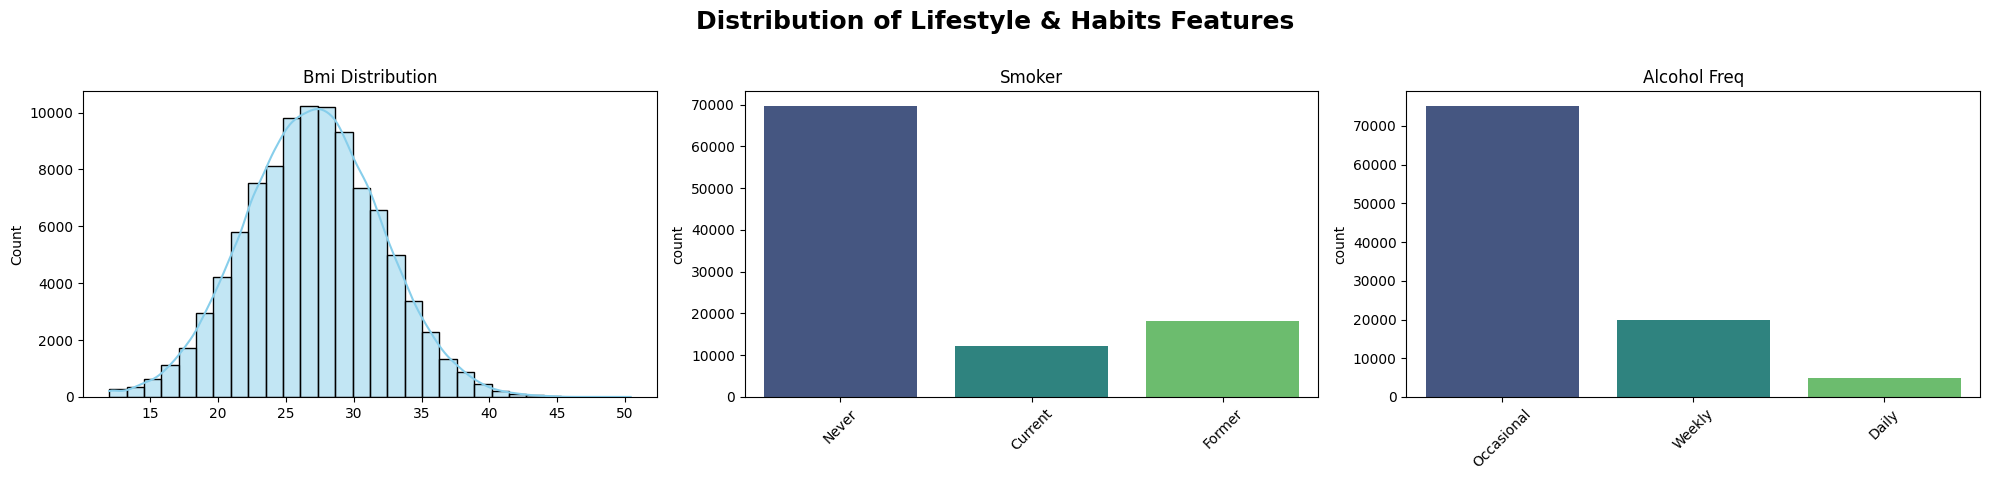

In [ ]:
# Lifestyle and Habits
# num: bmi
# cate: smoker, alcohol_freq
life_plots = len(life)
life_cols = 3 # each row has three subplots
life_rows = int(np.ceil(life_plots / life_cols))

fig, axes = plt.subplots(life_rows, life_cols, figsize=(20, life_rows * 5))
fig.suptitle('Distribution of Lifestyle & Habits Features', fontsize=18, fontweight='bold')

axes = axes.flatten()

for i, col in enumerate(life):
    ax = axes[i]

    # numerical column
    if col in ['bmi']:
      sns.histplot(df[col].dropna(), kde=True, ax=ax, bins=30, color='skyblue')
      ax.set_title(f'{col.title()} Distribution')
      ax.set_xlabel('')

    # categorical/binary column
    else:
      sns.countplot(x=col, data=df, ax=ax, palette='viridis', hue=col, legend=False)
      ax.set_title(f'{col.replace("_", " ").title()}')
      ax.set_xlabel('')

      ax.tick_params(axis='x', rotation=45) # reverse the xlabel 45 rotations

# hide subplots with no data
for i in range(len(life), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

**Lifestyle and Habits**

1. The BMI Distribution follows a normal distribution curve, centered around 25, which is classified as overweight.

2. A large majority of individuals in the dataset are Non-smokers (labeled as 'Never'). The number of current smokers is relatively low.

3. Most customers report Occasional alcohol consumption, with fewer reporting weekly or daily use.

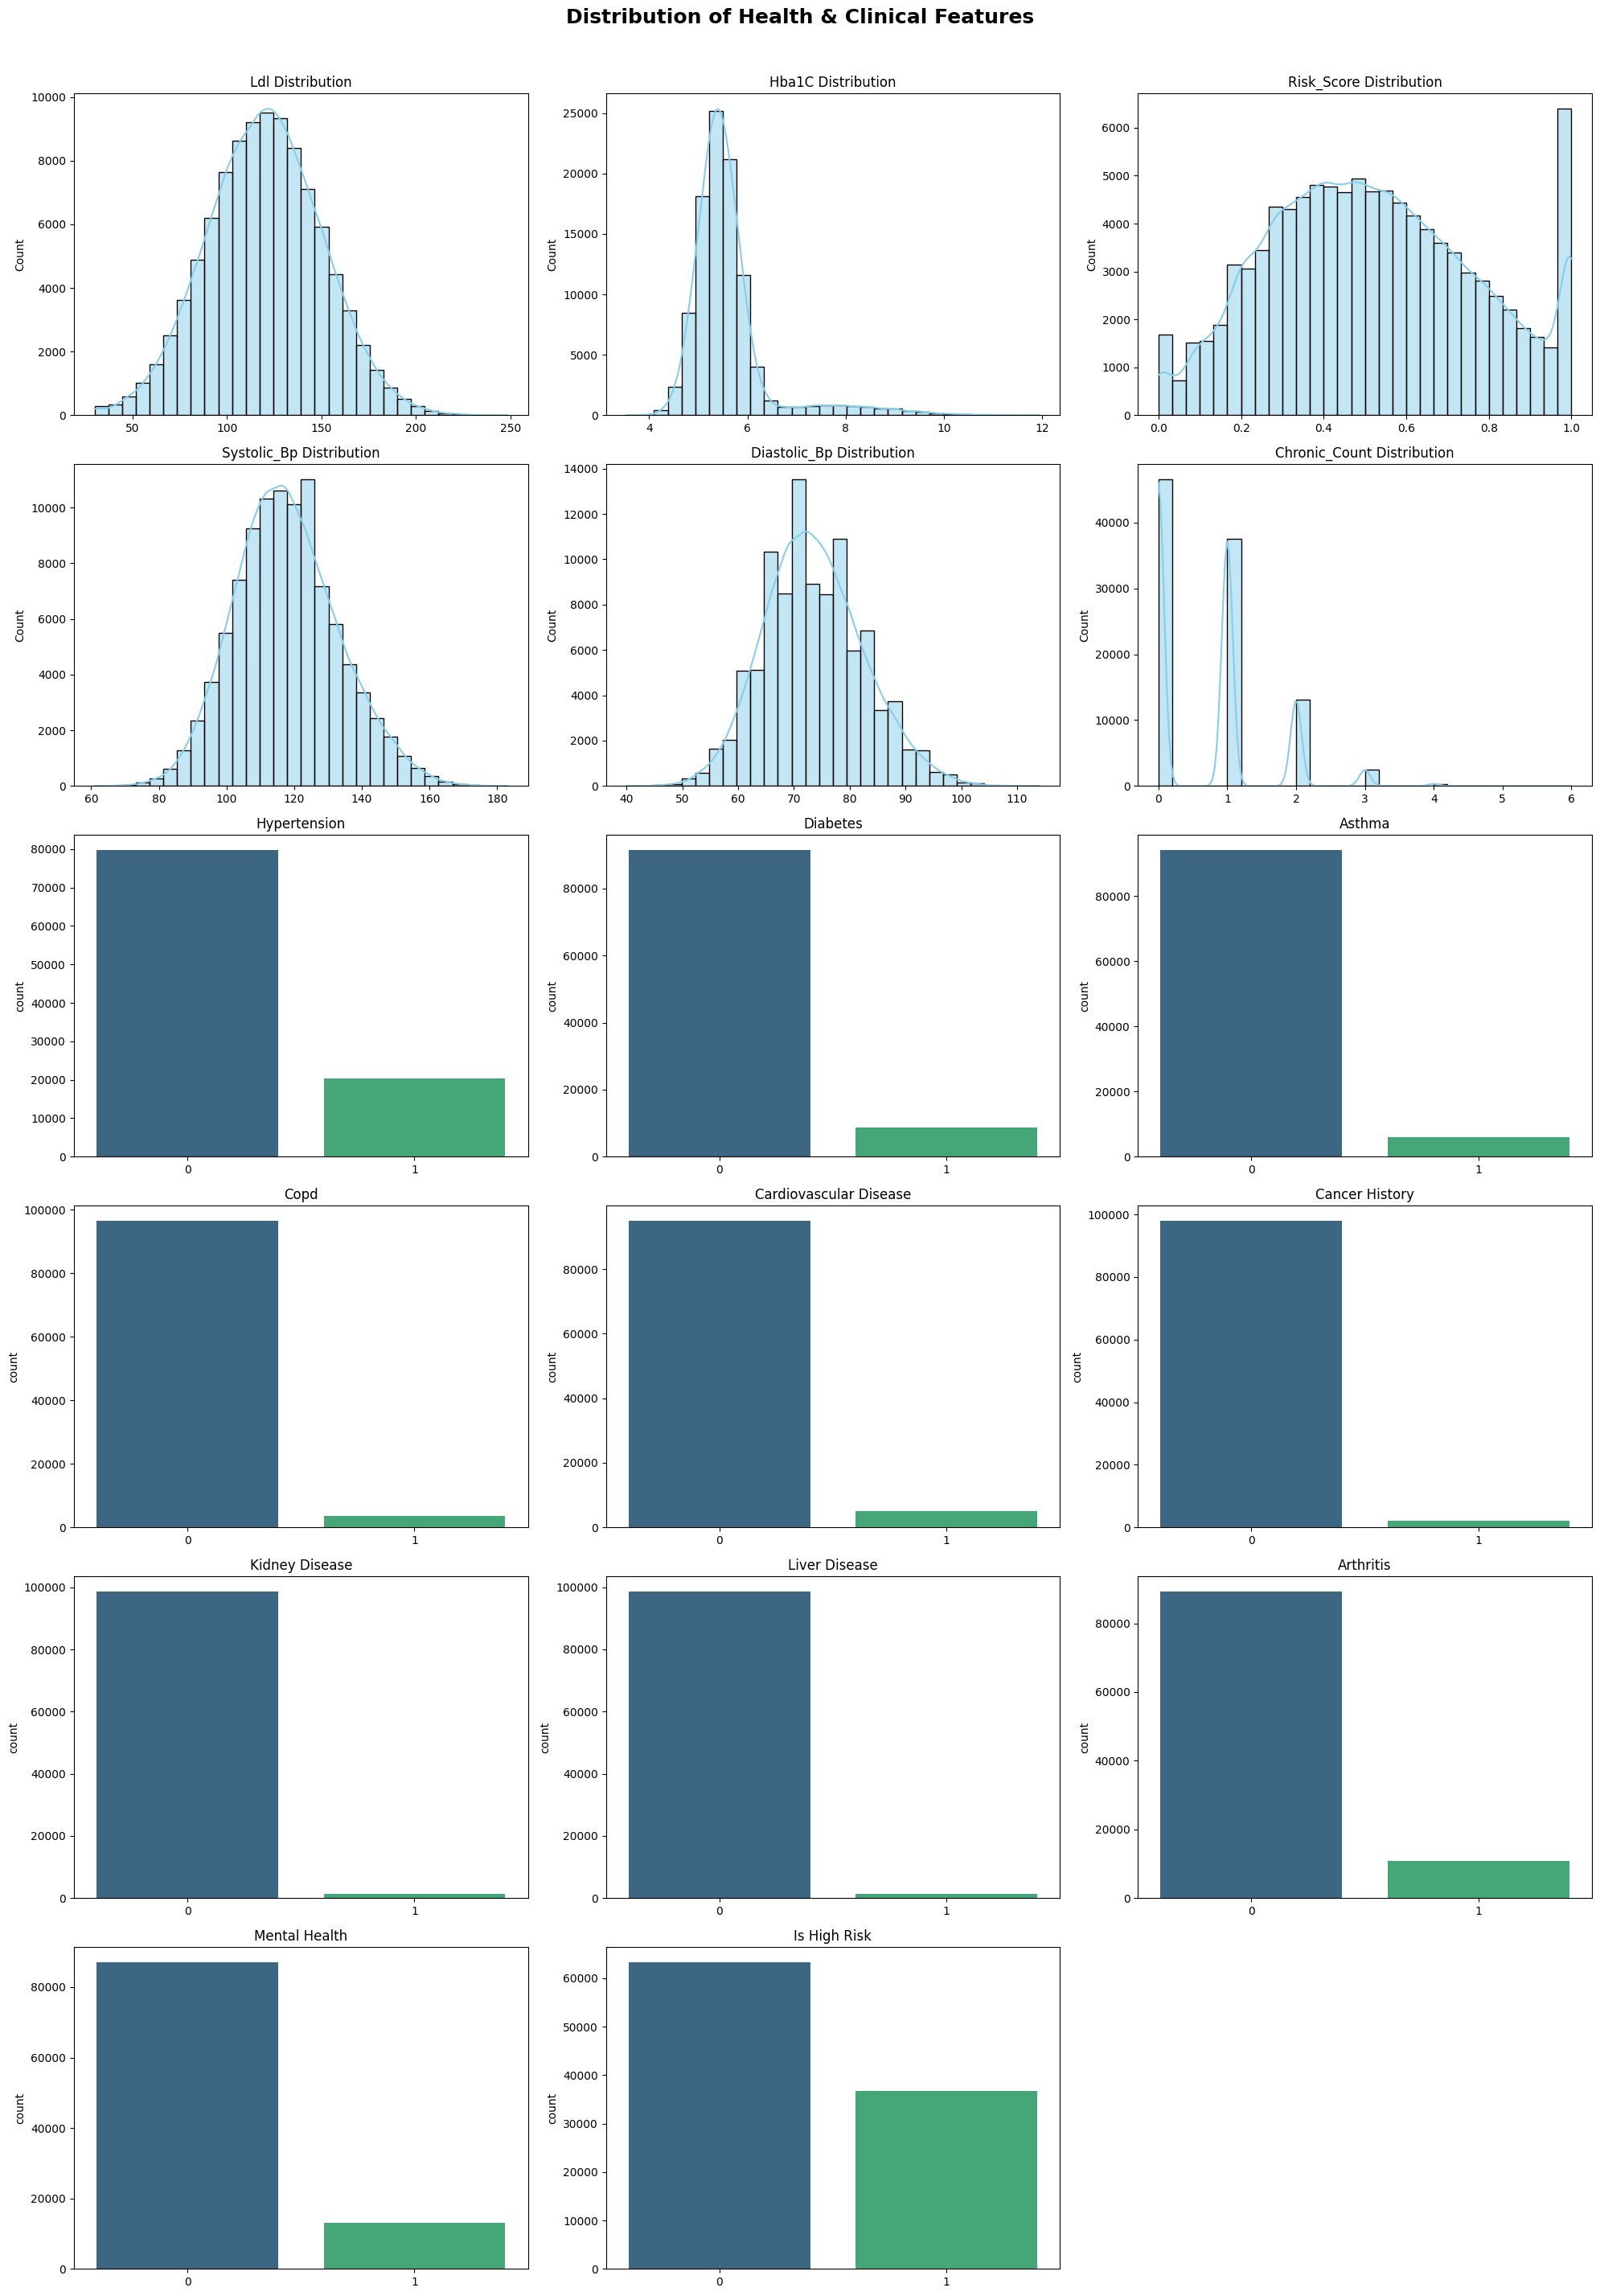

In [ ]:
# Health and Clinical
# num: systolic_bp, diastolic_bp, ldl, hba1c, risk_score, chronic_count
# binary: 'hypertension', 'diabetes', 'asthma', 'copd', 'cardiovascular_disease', 'cancer_history', 'kidney_disease',
# 'liver_disease', 'arthritis', 'mental_health', 'is_high_risk'
cli_plots = len(clinical)
cli_cols = 3 # each row has three subplots
cli_rows = int(np.ceil(cli_plots / cli_cols))

fig, axes = plt.subplots(cli_rows, cli_cols, figsize=(20, cli_rows * 5))
fig.suptitle('Distribution of Health & Clinical Features', fontsize=18, fontweight='bold')

axes = axes.flatten()

for i, col in enumerate(clinical):
    ax = axes[i]

    # numerical column
    if col in ['systolic_bp', 'diastolic_bp', 'ldl', 'hba1c', 'risk_score', 'chronic_count' ]:
      sns.histplot(df[col].dropna(), kde=True, ax=ax, bins=30, color='skyblue')
      ax.set_title(f'{col.title()} Distribution')
      ax.set_xlabel('')

    # categorical/binary column
    else:
      sns.countplot(x=col, data=df, ax=ax, palette='viridis', hue=col, legend=False)
      ax.set_title(f'{col.replace("_", " ").title()}')
      ax.set_xlabel('')


# hide subplots with no data
for i in range(len(clinical), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

Health and Clinical

1. The distributions for Ldl, hba1c, Systolic BP, and Diastolic BP all approximate a normal, bell-shaped distribution. This suggests these clinical measurements have good variability for modeling.

2. The Chronic Count Distribution is heavily concentrated at 0 and 1.

3. For almost all serious medical conditions (including Hypertension, Diabetes, Asthma, COPD, Cardiovascular Disease, and Cancer History), the vast majority of policyholders report a value of 0 (No Condition).
This pattern highlights that the dataset is dominated by generally healthy individuals.

4. The Risk Score Distribution is spread fairly evenly across its range. And the feature is_High_Risk variable shows that the majority of individuals are classified as low risk (0), but a significant portion (around 30%-40%) is categorized as high risk (1).

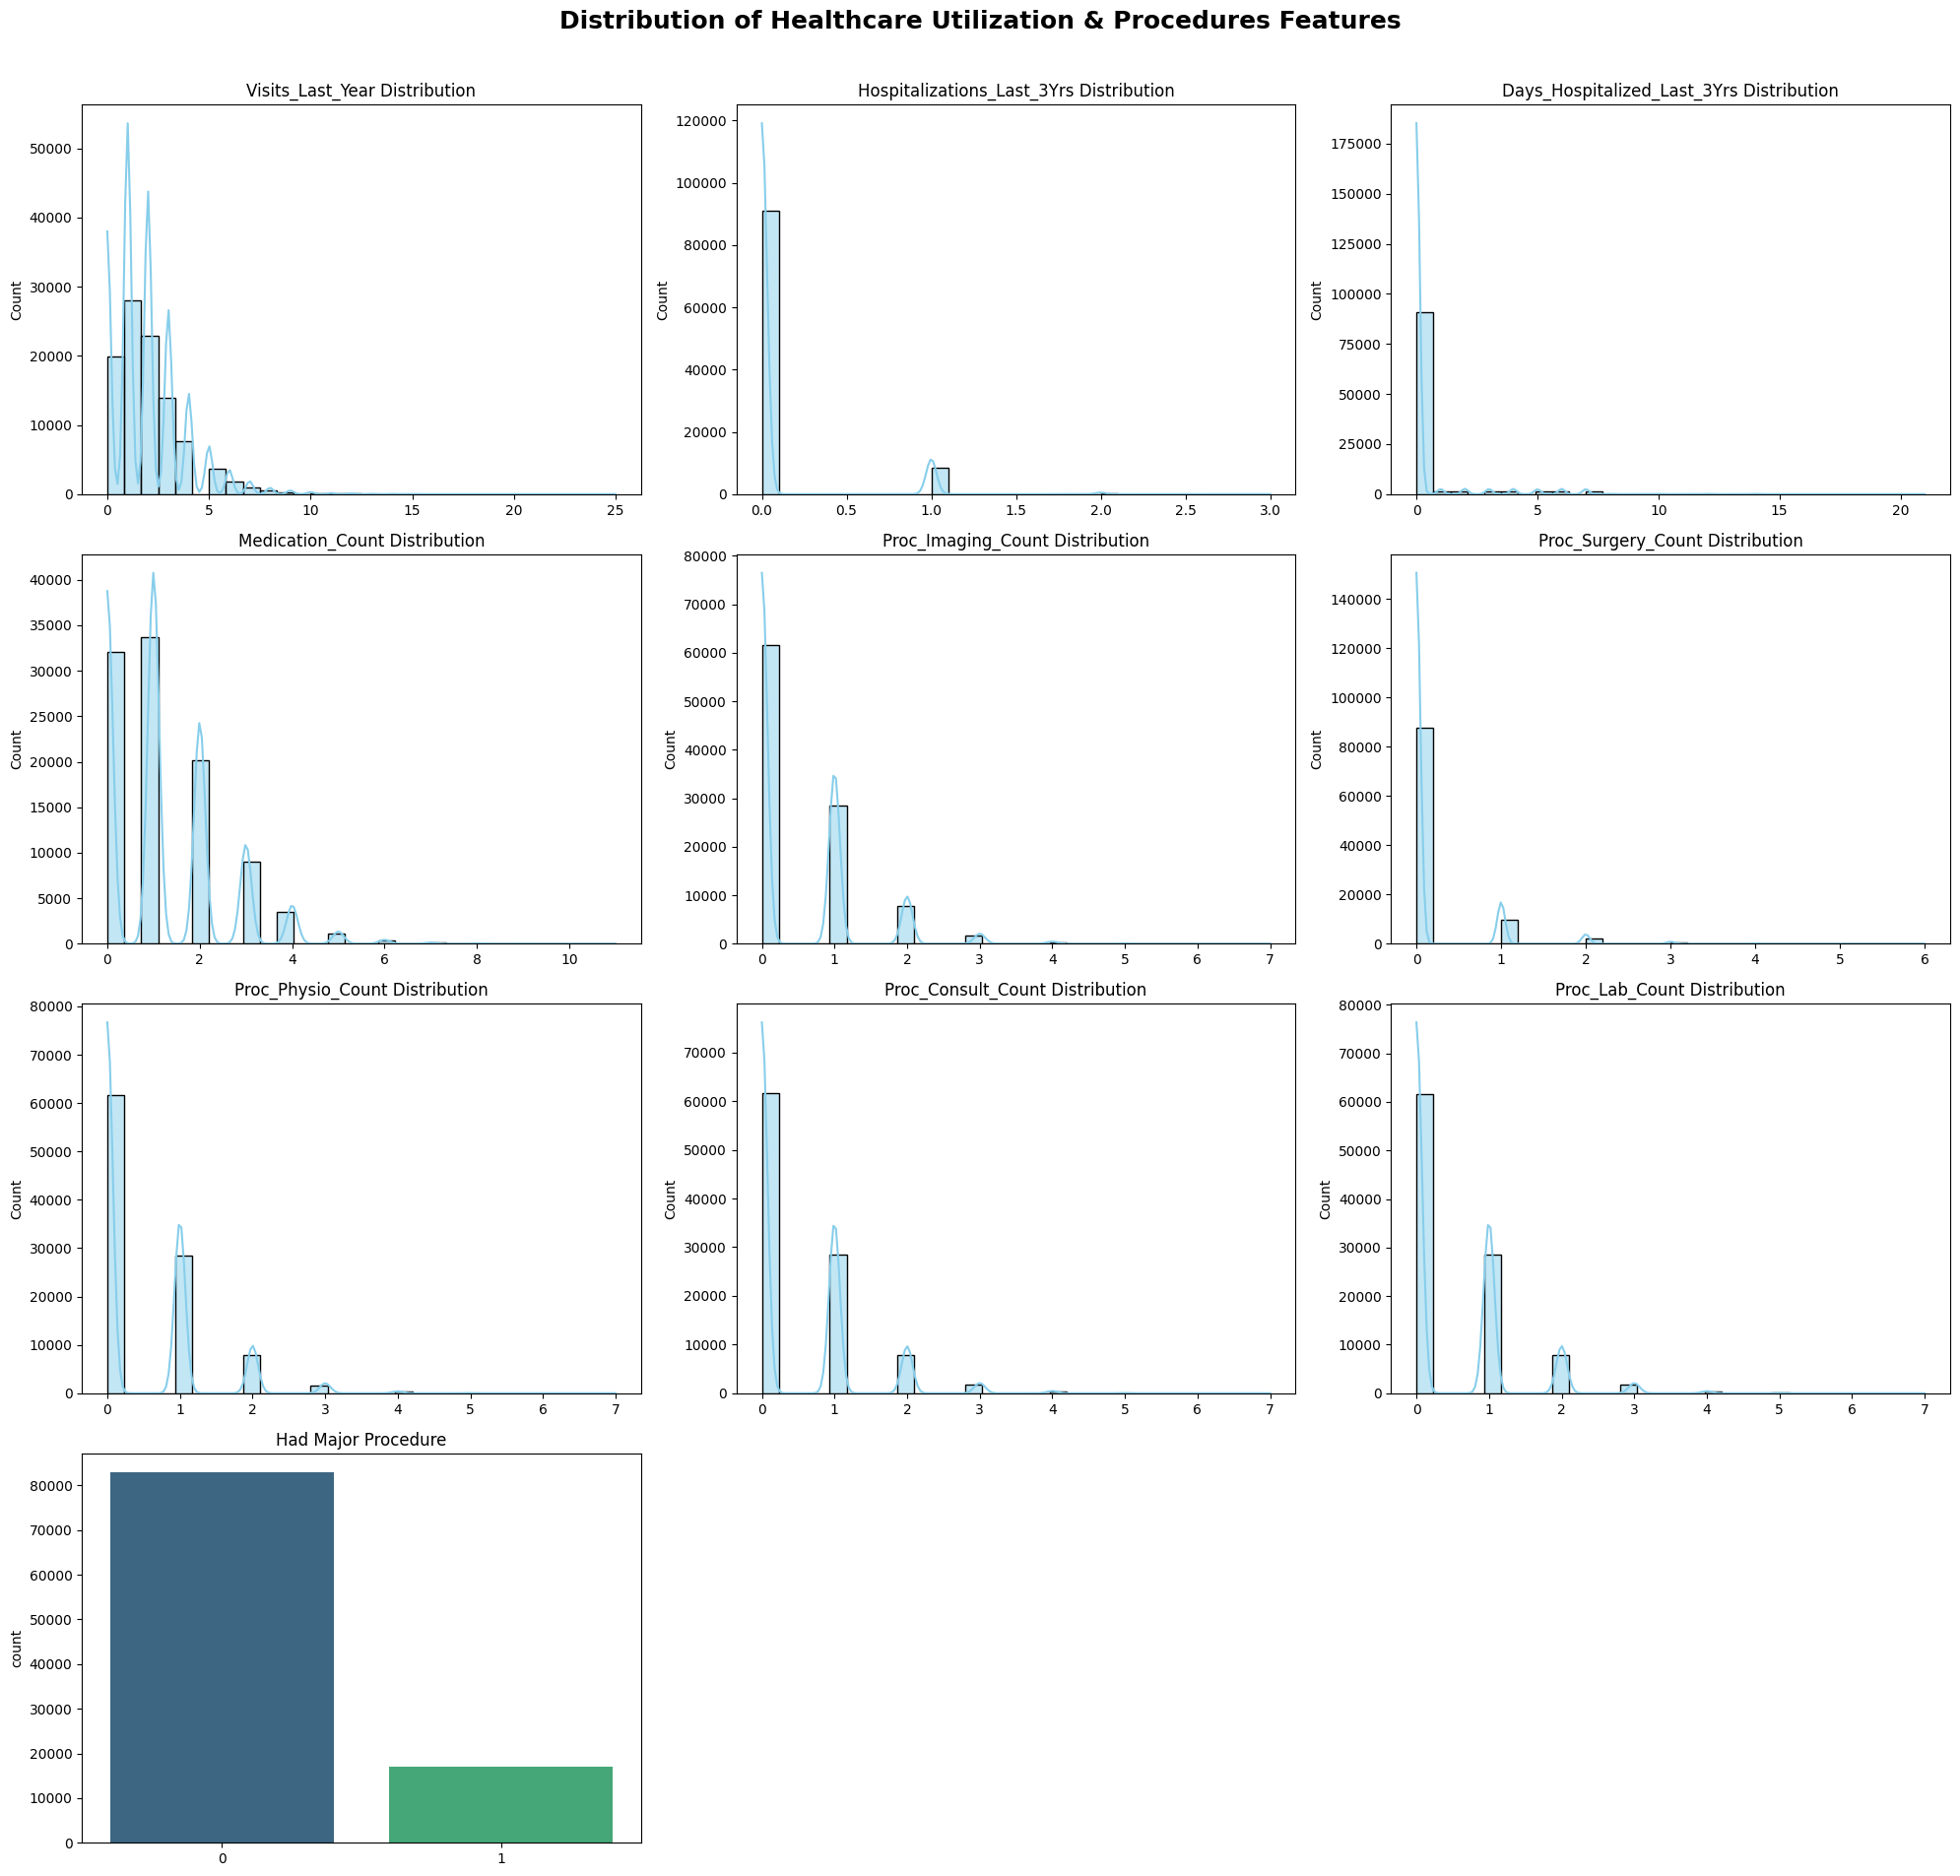

In [ ]:
# Healthcare Utilization and Procedures
# num: 'visits_last_year', 'hospitalizations_last_3yrs', 'days_hospitalized_last_3yrs',
# 'medication_count', 'proc_imaging_count', 'proc_surgery_count', 'proc_physio_count', 'proc_consult_count',
# 'proc_lab_count'
# binary: had_major_procedure
health_plots = len(healthcare)
health_cols = 3 # each row has three subplots
health_rows = int(np.ceil(health_plots / health_cols))

fig, axes = plt.subplots(health_rows, health_cols, figsize=(20, health_rows * 5))
fig.suptitle('Distribution of Healthcare Utilization & Procedures Features', fontsize=18, fontweight='bold')

axes = axes.flatten()

for i, col in enumerate(healthcare):
    ax = axes[i]

    # categorical/binary column
    if col in ['had_major_procedure']:
      sns.countplot(x=col, data=df, ax=ax, palette='viridis', hue=col, legend=False)
      ax.set_title(f'{col.replace("_", " ").title()}')
      ax.set_xlabel('')

    # numerical column
    else:
      sns.histplot(df[col].dropna(), kde=True, ax=ax, bins=30, color='skyblue')
      ax.set_title(f'{col.title()} Distribution')
      ax.set_xlabel('')


# hide subplots with no data
for i in range(len(healthcare), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

Healthcare Utilization and Procedures

1. Most continuous utilization variables, such as Visits Last Year, Hospitalizations Last 3 Yrs, and Days Hospitalized Last 3 Yrs, are heavily concentrated at zero or very low values. Thus the healthcare utilization for these customers is low.

2. Similarly, the counts for different medical procedures (Proc Imaging, Proc Surgery, Proc Physio, etc.) are also highly skewed toward zero.

3. This heavy skewness across almost all utilization features suggests that the majority of the dataset consists of policyholders who use minimal healthcare resources, while high-cost events are rare but significant outliers.

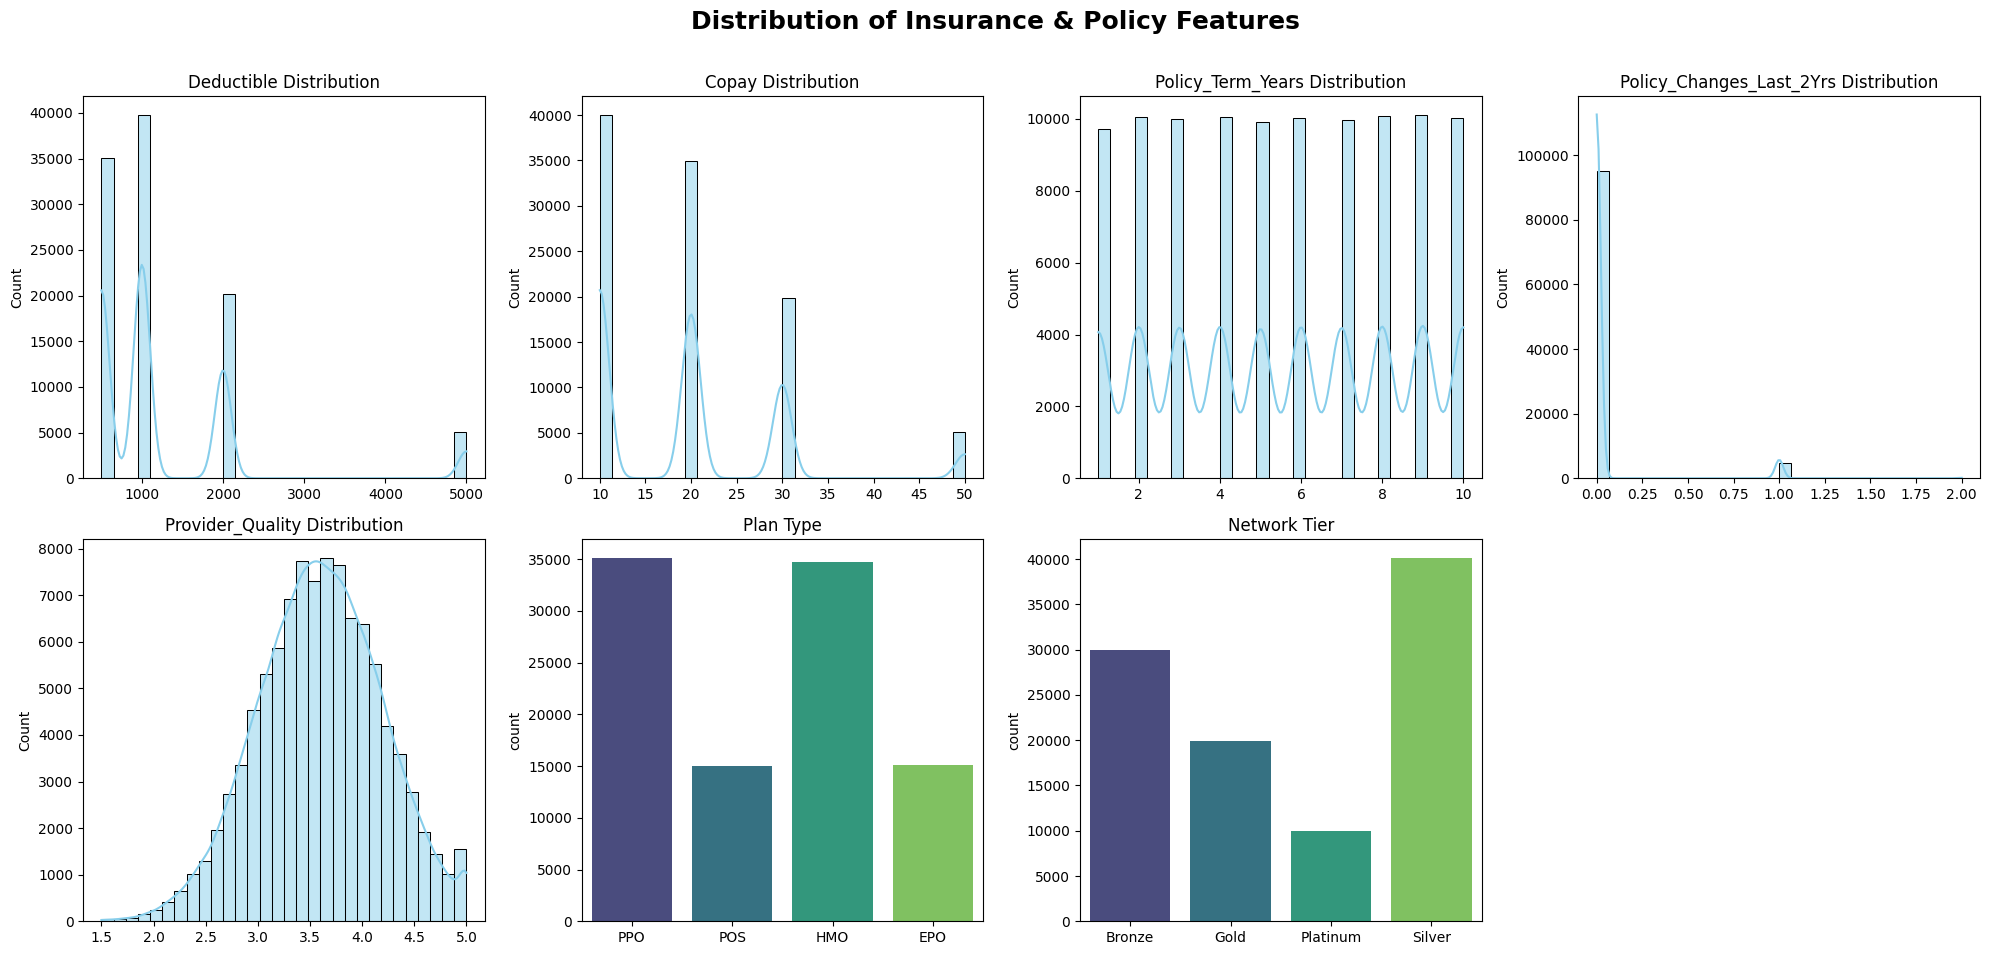

In [ ]:
# Insurance and Policy
# num: 'deductible', 'copay', 'policy_term_years', 'policy_changes_last_2yrs', 'provider_quality',
# cate: 'plan_type', 'network_tier'
in_plots = len(insurance)
in_cols = 4 # each row has four subplots
in_rows = int(np.ceil(in_plots / in_cols))

fig, axes = plt.subplots(in_rows, in_cols, figsize=(20, in_rows * 5))
fig.suptitle('Distribution of Insurance & Policy Features', fontsize=18, fontweight='bold')

axes = axes.flatten()

for i, col in enumerate(insurance):
    ax = axes[i]

    # numerical column
    if col in ['deductible', 'copay', 'policy_term_years', 'policy_changes_last_2yrs', 'provider_quality']:
      sns.histplot(df[col].dropna(), kde=True, ax=ax, bins=30, color='skyblue')
      ax.set_title(f'{col.title()} Distribution')
      ax.set_xlabel('')

    # categorical/binary column
    else:
      sns.countplot(x=col, data=df, ax=ax, palette='viridis', hue=col, legend=False)
      ax.set_title(f'{col.replace("_", " ").title()}')
      ax.set_xlabel('')


# hide subplots with no data
for i in range(len(insurance), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

Insurance and Policy

1. Both the Deductible Distribution and Copay Distribution are highly multi-modal (showing several distinct peaks).
Therefore, the insurance plans can be organized into a few clearly defined financial tiers (e.g., plans centered around low, medium, and high deductible amounts).
These tiers will likely be a significant factor in cost prediction.

2. The Policy Term Years Distribution is uniform across its range (1 to 10 years). This suggests the dataset tracks policies of all ages equally, without bias toward new or very old policies.

3. The Policy Changes Last 2 Yrs Distribution is severely skewed, with the vast majority of policies having zero changes in the last two years. This indicates high customer policy stability.

4. The Provider Quality Distribution is approximately normal (bell-shaped), centered around a score of 3.5. This shows good variance in the quality of healthcare received.

5. The Plan Distribution shows that the PPO and HMO plan types are the most popular choices among customers.

6. In Network Tier Distribution, customers show a strong preference for the Silver and Bronze Network Tiers, suggesting a general tendency to select moderately priced or basic coverage plans over Platinum or Gold.

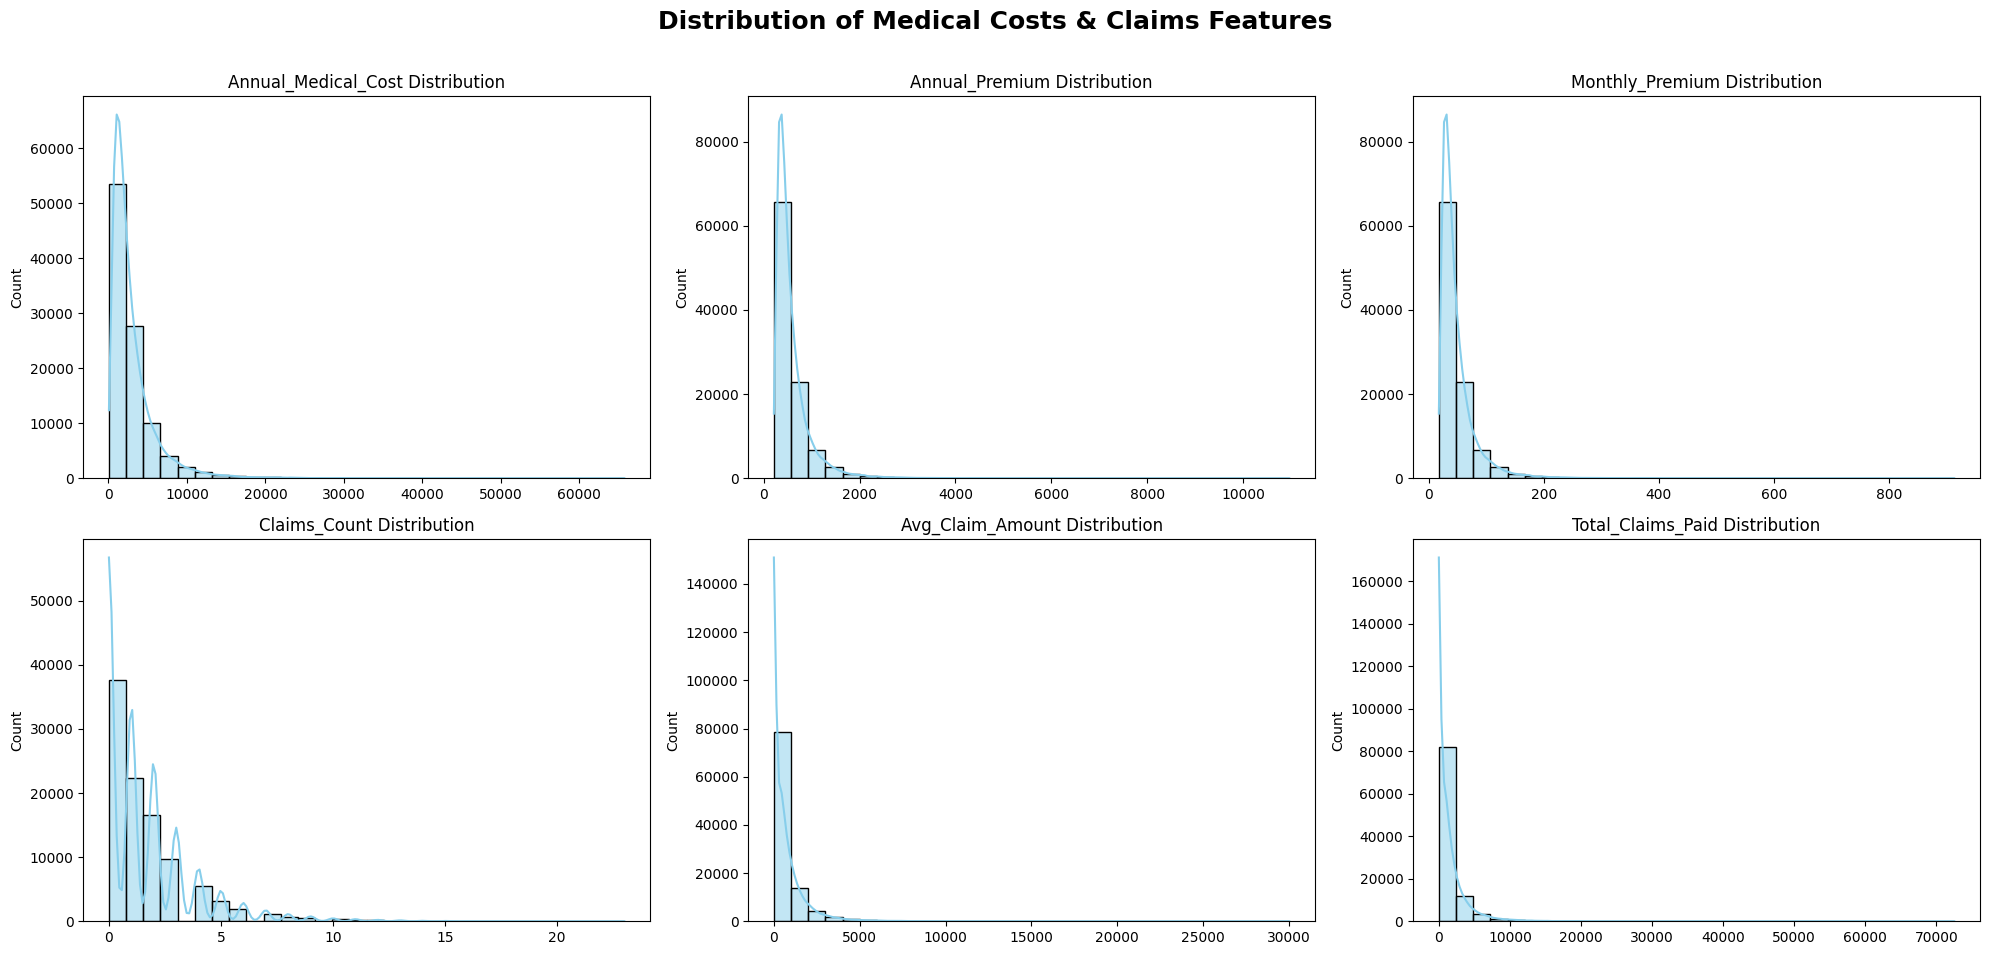

In [ ]:
# Medical Costs and Claims
# num: 'annual_medical_cost', 'annual_premium', 'monthly_premium', 'claims_count',
# 'avg_claim_amount', 'total_claims_paid'
# cate:
# binary:
cost_plots = len(cost)
cost_cols = 3 # each row has three subplots
cost_rows = int(np.ceil(cost_plots / cost_cols))

fig, axes = plt.subplots(cost_rows, cost_cols, figsize=(20, cost_rows * 5))
fig.suptitle('Distribution of Medical Costs & Claims Features', fontsize=18, fontweight='bold')

axes = axes.flatten()

for i, col in enumerate(cost):
    ax = axes[i]

    sns.histplot(df[col].dropna(), kde=True, ax=ax, bins=30, color='skyblue')
    ax.set_title(f'{col.title()} Distribution')
    ax.set_xlabel('')

# hide subplots with no data
for i in range(len(cost), len(axes)):
    axes[i].set_visible(False)

plt.tight_layout(rect=[0, 0.03, 1, 0.97])
plt.show()

Medical Costs and Claims

1. The distribution of the target variable 'Annual_Medical_Cost' is highly skewed to the right (positively skewed).
A vast majority of customers incur very low costs (clustered near zero), while a small number of individuals account for extremely high costs (outliers).

2. The distributions for Claims_Count, Avg_Claim_Amount, and Total_Claims_Paid show a pattern identical to the target cost: they are all highly skewed to the right, with most values near zero.

3. Both Annual_Premium and Monthly_Premium distributions are also highly skewed to the right. This skewness is expected, as premiums are typically set to reflect the underlying risk distribution.

In [ ]:
# numerical column: 30
numerical_cols = [
    'age', 'income', 'household_size', 'dependents', 'bmi',
    'visits_last_year', 'hospitalizations_last_3yrs', 'days_hospitalized_last_3yrs',
    'medication_count', 'systolic_bp', 'diastolic_bp', 'ldl', 'hba1c',
    'deductible', 'copay', 'policy_term_years', 'policy_changes_last_2yrs',
    'provider_quality', 'risk_score', 'annual_premium', 'monthly_premium',
    'claims_count', 'avg_claim_amount', 'total_claims_paid', 'chronic_count',
    'proc_imaging_count', 'proc_surgery_count', 'proc_physio_count',
    'proc_consult_count', 'proc_lab_count'
]

# categorical column: 10
categorical_cols = [
    'sex', 'region', 'urban_rural', 'education', 'marital_status',
    'employment_status', 'alcohol_freq', 'plan_type', 'network_tier',
    'smoker'
]

# binary column: 12
binary_cols = [
    'hypertension', 'diabetes', 'asthma', 'copd',
    'cardiovascular_disease', 'cancer_history', 'kidney_disease',
    'liver_disease', 'arthritis', 'mental_health', 'had_major_procedure',
    'is_high_risk'
]

Then plot again the histplot and kernel density estimation (KDE) of annual_medical_cost, which is the prediction label.

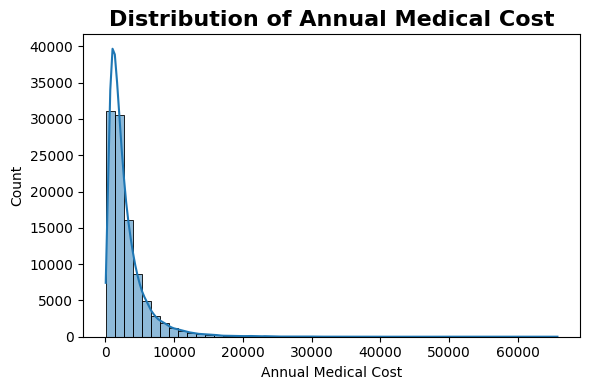

In [ ]:
fig, ax = plt.subplots(1, 1, figsize=(6, 4))

# Plot a histplot and kernel density estimation (KDE) of annual_medical_cost
sns.histplot(df['annual_medical_cost'],
             kde=True,
             ax=ax,
             bins=50,
             edgecolor='black')

ax.set_title('Distribution of Annual Medical Cost',
             fontsize=16,
             fontweight='bold')
ax.set_xlabel('Annual Medical Cost')
ax.set_ylabel('Count')

plt.tight_layout()
plt.show()

The distribution of Annual Medical Cost shows a pronounced positive skew, indicating that most individuals incurred costs in the 0 to 20,000 range."

A long tail extends from 20,000 up to 70,000, representing a small number of high-cost values.

### Data Preprocessing

First, divide features and label(annual_medical_cost). Meanwhile, the feature person_id will be dropped because it has no mean in this task.

In [ ]:
X = df.drop(columns=['person_id', 'annual_medical_cost'], axis=1)
y = df['annual_medical_cost']

In [ ]:
print(X.shape)
print(X.head())

(100000, 52)
   age     sex   region urban_rural   income     education marital_status employment_status  household_size  dependents   bmi smoker alcohol_freq  visits_last_year  hospitalizations_last_3yrs  days_hospitalized_last_3yrs  medication_count  systolic_bp  diastolic_bp    ldl  hba1c plan_type network_tier  deductible  copay  policy_term_years  policy_changes_last_2yrs  provider_quality  risk_score  annual_premium  monthly_premium  claims_count  avg_claim_amount  total_claims_paid  chronic_count  hypertension  diabetes  asthma  copd  cardiovascular_disease  cancer_history  kidney_disease  liver_disease  arthritis  mental_health  proc_imaging_count  proc_surgery_count  proc_physio_count  proc_consult_count  proc_lab_count  is_high_risk  had_major_procedure
0   52  Female    North    Suburban  22700.0     Doctorate        Married           Retired               3           1  27.4  Never   Occasional                 2                           0                            0      

In [ ]:
print(y.shape)
print(y.head())

(100000,)
0    6938.06
1    1632.61
2    7661.01
3    5130.27
4    1700.73
Name: annual_medical_cost, dtype: float64


Then, split training and testing set in 7:3 ratio.

In [ ]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.base import BaseEstimator, TransformerMixin
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer

In [ ]:
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    test_size=0.3,
                                                    random_state=913)

print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(70000, 52)
(30000, 52)
(70000,)
(30000,)


The execution of fitting the preprocessor must only happen after the data has been split into training set and testing set.

Because Standardization relies on calculating the mean and standard deviation of the features. If calculating these parameters on the full dataset and then split, information from the test set leaks into the training set's calculated parameters. This artificially inflates the model's performance on the test data.

Then, perform data preprocessing (such as feature standardization or normalization)

1. Standardize the numerical features.

$$z_i = \frac{x_i - \mu}{\sigma}$$

*   $x_i$: original values of feature
*   $\mu$: mean value of feature
*   $\sigma$: Standard Deviation

2. Using One-hot Encoding to the categorical features.

*   Create a new binary column(value is 0 or 1) for each unique category, ensuring that the model interprets these features as distinct entities rather than ordered values.

In [ ]:
# define StandardScaler transformer: normalizing numerical features to mean=0, std=1
num_transformer = StandardScaler()

# define OneHotEncoder transformer: converting categorical features into binary columns
cat_transformer = OneHotEncoder(handle_unknown='ignore', drop='first')

# construct ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, numerical_cols),
        ('cat', cat_transformer, categorical_cols)
    ],
    remainder='passthrough' # donot process binary columns
)

print("constructing ColumnTransformer success.")

constructing ColumnTransformer success.


In [ ]:
# learn the parameters and transform the data simultaneously
# training set
X_train_processed = preprocessor.fit_transform(X_train)

# testing set
X_test_processed = preprocessor.transform(X_test)

print(type(X_train_processed), X_train_processed.shape)
print(type(X_test_processed), X_test_processed.shape)

<class 'numpy.ndarray'> (70000, 71)
<class 'numpy.ndarray'> (30000, 71)


Next Visualize correlation matrix. Based on the processed data, calculating their correlation with label(annual_medical_cost), and plotting a heatmap in order to display result clearly.

In [ ]:
# get all feature names
feature_names = preprocessor.get_feature_names_out()

# convert X_train_processed into dataframe
X_train_df_processed = pd.DataFrame(X_train_processed,
                          index=X_train.index,
                          columns=feature_names)

# add label(annual_medical_cost)
X_train_df_processed['annual_medical_cost'] = y_train

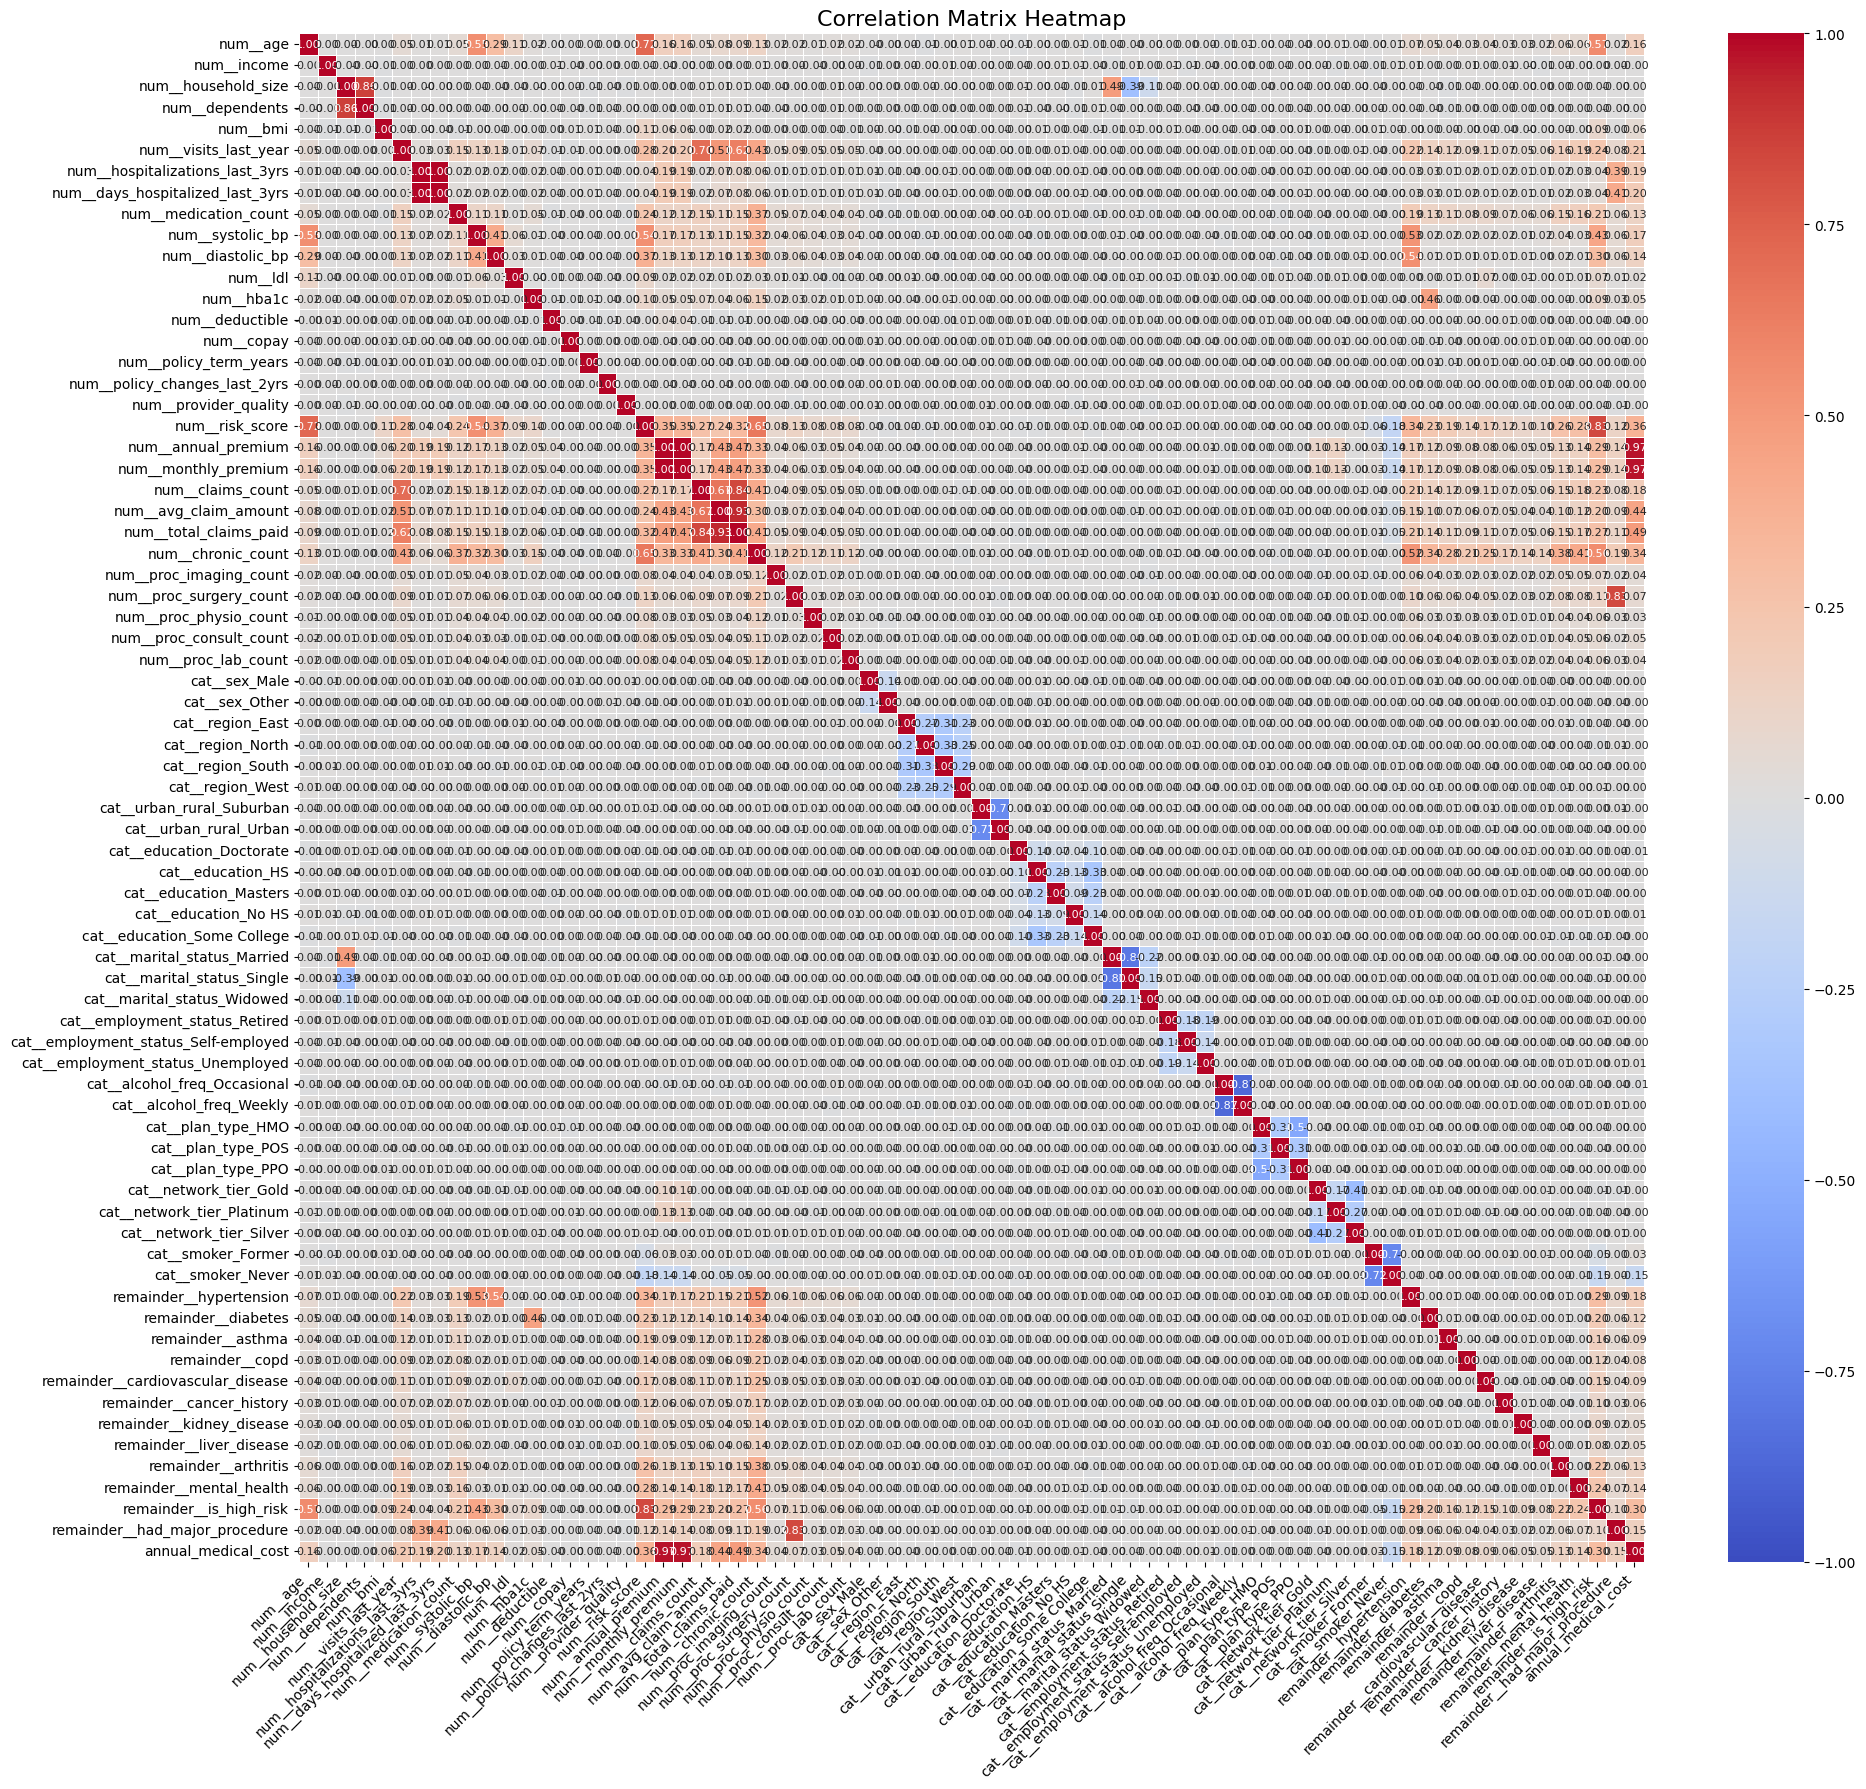

The correlation with annual_medical_cost:
 annual_medical_cost                 1.00
num__monthly_premium                0.97
num__annual_premium                 0.97
num__total_claims_paid              0.49
num__avg_claim_amount               0.44
num__risk_score                     0.36
num__chronic_count                  0.34
remainder__is_high_risk             0.30
num__visits_last_year               0.21
num__days_hospitalized_last_3yrs    0.20
num__hospitalizations_last_3yrs     0.19
num__claims_count                   0.18
remainder__hypertension             0.18
num__systolic_bp                    0.17
num__age                            0.16
cat__smoker_Never                   0.15
remainder__had_major_procedure      0.15
num__diastolic_bp                   0.14
remainder__mental_health            0.14
num__medication_count               0.13
remainder__arthritis                0.13
Name: annual_medical_cost, dtype: float64


In [ ]:
# calculate the correlation coefficient matrix
correlation_matrix = X_train_df_processed.corr(method='spearman').round(2)

# plot correlation matrix
plt.figure(figsize=(20, 18))

# heatmap using seaborn
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    linewidths=.5,           # the spacing between cells
    vmin=-1, vmax=1,         # set Color Range
    cbar=True,
    annot_kws={"size": 8}
)

plt.title('Correlation Matrix Heatmap', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# show the correlation with annual_medical_cost
# The highest column is annual_medical_cost itself
correlation_to_cost = correlation_matrix['annual_medical_cost'].abs().sort_values(ascending=False).head(21)

print('The correlation with annual_medical_cost:\n', correlation_to_cost)

**Data Leakage**

For features 'num__annual_premium' and 'num__monthly_premium', because they have too high correlation with label and each other, it will lead to data leakage if remaining one or both of them in the dataset.

**Multicollinearity Assessment**

It is essential to assess multicollinearity among the independent predictor variables. Multicollinearity occurs when two or more independent features are highly correlated with each other. This is a problem because it can lead to:

* Unstable Model Coefficients: Making coefficients (especially in linear models like Lasso and Ridge) highly sensitive to small changes in data.

* Redundancy: Adding unnecessary complexity to the model without contributing new information.


In [ ]:
# not consider the label annual_medical_cost
X_correlation_matrix = correlation_matrix.drop(
    ['annual_medical_cost'],
    axis=0
).drop(
    ['annual_medical_cost'],
    axis=1
)

# the threshold of Multicollinearity Assessment
threshold = 0.8

# each feature compares with other features without itself
upper = X_correlation_matrix.where(np.triu(np.ones(X_correlation_matrix.shape), k=1).astype(bool))

print(f"Features with Pairwise Correlation > {threshold}")
for i, column in enumerate(upper.columns):
    # find the row indices in the current column where the correlation exceeds the threshold
    highly_correlated_features = upper.index[upper[column].abs() > threshold].tolist()

    if highly_correlated_features:
        print(f"{column} is highly correlated with: {highly_correlated_features}")

Features with Pairwise Correlation > 0.8
num__dependents is highly correlated with: ['num__household_size']
num__days_hospitalized_last_3yrs is highly correlated with: ['num__hospitalizations_last_3yrs']
num__monthly_premium is highly correlated with: ['num__annual_premium']
num__total_claims_paid is highly correlated with: ['num__claims_count', 'num__avg_claim_amount']
cat__alcohol_freq_Weekly is highly correlated with: ['cat__alcohol_freq_Occasional']
remainder__is_high_risk is highly correlated with: ['num__risk_score']
remainder__had_major_procedure is highly correlated with: ['num__proc_surgery_count']


Set the threshold is 0.8, and find the features highly correlated with each other. And most of the features are from Medical Costs and Claims type.

Therefore, these features represent redundant and highly intertwined measures of utilization that require drop.

The deletion method is removing features with lower correlation to the label while retaining those with the highest one.

In [ ]:
# drop features(data leakage and multicollinearity)
drop_features = ['num__annual_premium', 'num__monthly_premium', 'num__dependents', 'num__hospitalizations_last_3yrs',
                 'num__claims_count', 'cat__alcohol_freq_Weekly',
                 'remainder__is_high_risk', 'num__proc_surgery_count']

X_train_df_processed = X_train_df_processed.drop(columns=drop_features, errors='ignore')

new_correlation_matrix = X_train_df_processed.corr(method='spearman').round(2)
# show the highest 20 correlation with annual_medical_cost
# The highest column is annual_medical_cost itself, so shift it one position to the right to take the 20th column
new_correlation_to_cost = new_correlation_matrix['annual_medical_cost'].abs().sort_values(ascending=False).head(26)

print('The highest 20 correlation with annual_medical_cost:\n', new_correlation_to_cost)

The highest 20 correlation with annual_medical_cost:
 annual_medical_cost                  1.00
num__total_claims_paid               0.49
num__avg_claim_amount                0.44
num__risk_score                      0.36
num__chronic_count                   0.34
num__visits_last_year                0.21
num__days_hospitalized_last_3yrs     0.20
remainder__hypertension              0.18
num__systolic_bp                     0.17
num__age                             0.16
remainder__had_major_procedure       0.15
cat__smoker_Never                    0.15
num__diastolic_bp                    0.14
remainder__mental_health             0.14
remainder__arthritis                 0.13
num__medication_count                0.13
remainder__diabetes                  0.12
remainder__asthma                    0.09
remainder__cardiovascular_disease    0.09
remainder__copd                      0.08
num__bmi                             0.06
remainder__cancer_history            0.06
remainder__liver_disea

Implement a filter-based feature selection by choosing the top 20 features with the highest absolute correlation to the label(Annual Medical Cost).

1. Reduce Dimensionality and Noise: Reduce the number of features from 71 down to 20. This step removes noise and redundant information, which helps to simplify the model and accelerate training time.

2. Maximize Signal Strength: By prioritizing the features with the strongest correlation (both positive and negative), we ensure that our model is trained only on the most predictive signals, leading to a more focused and interpretable model.



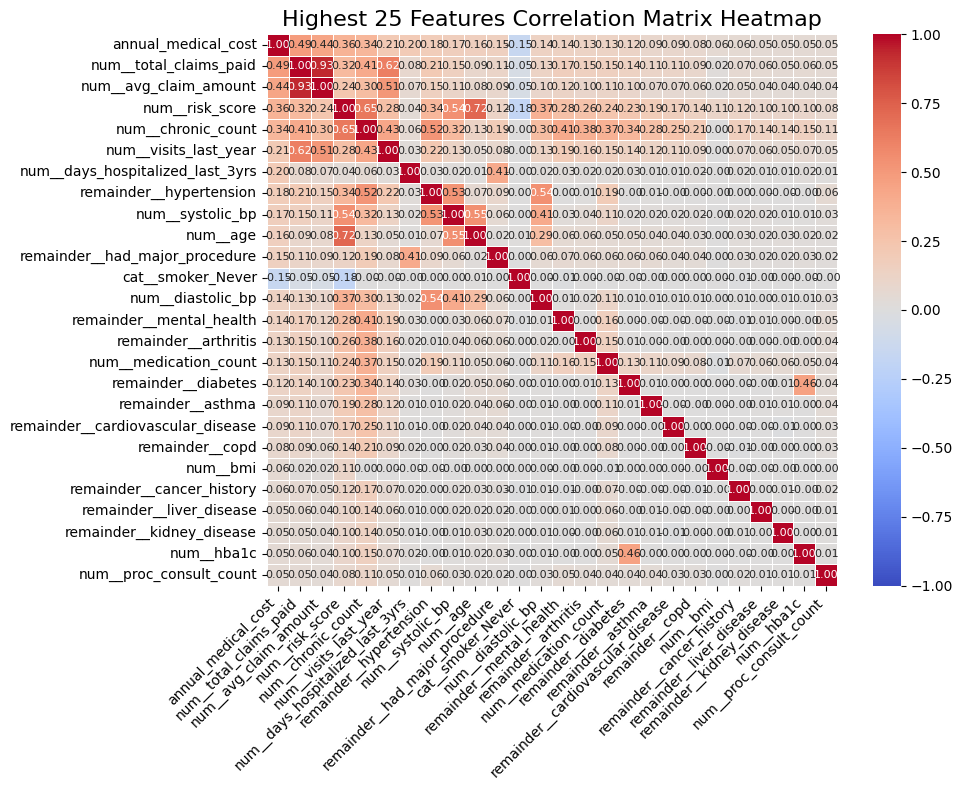

In [ ]:
# the highest 25 features with label
selected_features = [
    'num__total_claims_paid', 'num__avg_claim_amount', 'num__risk_score', 'num__chronic_count',
    'num__visits_last_year', 'num__days_hospitalized_last_3yrs', 'remainder__hypertension', 'num__systolic_bp',
    'num__age', 'remainder__had_major_procedure', 'cat__smoker_Never', 'num__diastolic_bp',
    'remainder__mental_health', 'remainder__arthritis', 'num__medication_count',
    'remainder__diabetes', 'remainder__asthma', 'remainder__cardiovascular_disease',
    'remainder__copd', 'num__bmi', 'remainder__cancer_history', 'remainder__liver_disease',
    'remainder__kidney_disease', 'num__hba1c', 'num__proc_consult_count'
]

selected_features_label = ['annual_medical_cost'] + selected_features

X_train_df_keep = X_train_df_processed[selected_features_label]

# calculate the correlation coefficient matrix
correlation_matrix = X_train_df_keep.corr(method='spearman').round(2)

# plot correlation matrix
plt.figure(figsize=(10, 8))

# show new and more clear heatmap
sns.heatmap(
    correlation_matrix,
    annot=True,
    fmt=".2f",
    cmap='coolwarm',
    linewidths=.5,           # the spacing between cells
    vmin=-1, vmax=1,         # set Color Range
    cbar=True,
    annot_kws={"size": 8}
)

plt.title('Highest 25 Features Correlation Matrix Heatmap', fontsize=16)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

Find the column indices corresponding to selected_features, then slice the training and testing set.

In [ ]:
# find the position of selected_features in feature_names
feature_indices_to_keep = [
    np.where(feature_names == feature_name)[0][0]
    for feature_name in selected_features
]
# check out there is correct number of features
if len(feature_indices_to_keep) != len(selected_features):
    print("Index lengths do not match.")

# keep only the selected columns in training and testing set
X_train_final = X_train_processed[:, feature_indices_to_keep]

X_test_final = X_test_processed[:, feature_indices_to_keep]

print(f"X_train_final: {X_train_final.shape}")
print(f"X_test_final: {X_test_final.shape}")

X_train_final: (70000, 25)
X_test_final: (30000, 25)


### Regression: Train model


**Random Forest**

Use Random Forest Model, because it demonstrated the strong ensemble power and robustness, which can significantly lead to much more accurate predictions and resist to overfitting.

Its important parameters including n_estimators (the number of trees, defaulting to 100) and max_features (the number of features considered per tree, defaulting to sqrt).

In [ ]:
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# initial Random Forest model
rf_model = RandomForestRegressor(
    n_estimators=500,
    max_depth=10,
    min_samples_split=10,
    min_samples_leaf=5,
    max_features=0.7,  # consider 70% feature subsets during search
    n_jobs=-1,
    random_state=42
)

print("Train Random Forest Model.")

# fit model
rf_model.fit(X_train_final, y_train)

print("\nComplete Model Training.")

Train Random Forest Model.

Complete Model Training.


Evaluate Random Forest Model

Using the three metrics: $R^2$, RMSE, and MAE, Evaluating the accuracy of this random forest model.

1. $R^2$: It represents the proportion of the variance in the dependent variable (Annual Cost) that is predictable from the independent variables (features). A score closer to 1.0 is better. And it tells us the overall explanatory power of our selected features.

2. RMSE: It is the square root of the average squared error. Since errors are squared, RMSE penalizes large errors (outliers) much more heavily than MAE. So it can focus on High-Cost Errors.

3. It is the average of the absolute differences between true and predicted values, which is used to measure typical accuracy.

In [ ]:
# predict(log transformation)
rf_predict = rf_model.predict(X_test_final)

# Metrics
rf_r2 = r2_score(y_test, rf_predict)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predict))
rf_mae = mean_absolute_error(y_test, rf_predict)

print('Random Forest Evaluation')
print(f'R2: {rf_r2:.4f}')
print(f'RMSE: {rf_rmse:.4f}')
print(f'MAE: {rf_mae:.4f}')

Random Forest Evaluation
R2: 0.7003
RMSE: 1704.9473
MAE: 964.0684


1. $R^2$ 0.7003 means the model explains 70.03% of the variance in medical costs, which include the most part of data.

2. RMSE 1704.9438 is a very competitive figure, indicating a low average error magnitude, even considering the penalty for high-cost predictions.

3. MAE 963.6566 is significantly lower than RMSE, suggesting the model is more accurate for the majority of the population (the lower cost range).

**Lasso/Ridge Regression:**

They address this issue through **"regularization"**. They add a "penalty term" during model training, which penalizes excessively large model coefficients (weights).

In [ ]:
#lasso regression
from sklearn.linear_model import Lasso, Ridge

lasso_model = Lasso(alpha=1)

lasso_model.fit(X_train_final, y_train)

# Make predictions on the test set.
y_pred_lasso = lasso_model.predict(X_test_final)

# Evaluation of Lasso Model
rmse_lasso = np.sqrt(mean_squared_error(y_test, y_pred_lasso))
r2_lasso = r2_score(y_test, y_pred_lasso)
mae_lasso = mean_absolute_error(y_test, y_pred_lasso)

print("Lasso Regression - Evaluation Results:")
print(f"R² (determination coefficient): {r2_lasso:.4f}")
print(f"root-mean-square error (RMSE): {rmse_lasso:.4f}")
print(f"mean_absolute_error (MAE): {mae_lasso:.4f}")

Lasso Regression - Evaluation Results:
R² (determination coefficient): 0.6053
root-mean-square error (RMSE): 1956.7824
mean_absolute_error (MAE): 1191.4303


In [ ]:
#ridge regression
ridge_model = Ridge(alpha=1)

# Train the model using the processed training data.
ridge_model.fit(X_train_final, y_train)

# Make predictions on the test set.
y_pred_ridge = ridge_model.predict(X_test_final)


# Evaluating the Ridge Model
rmse_ridge = np.sqrt(mean_squared_error(y_test, y_pred_ridge))
r2_ridge = r2_score(y_test, y_pred_ridge)
mae_ridge = mean_absolute_error(y_test, y_pred_ridge)

print("Ridge Regression - Evaluation Results:")
print(f"R² (determination coefficient): {r2_ridge:.4f}")
print(f"root-mean-square error (RMSE): {rmse_ridge:.4f}")
print(f"mean_absolute_error (MAE): {mae_ridge:.4f}")

Ridge Regression - Evaluation Results:
R² (determination coefficient): 0.6053
root-mean-square error (RMSE): 1956.7674
mean_absolute_error (MAE): 1191.5429


All evaluation metrics (RMSE, R², MAE) for Lasso and Ridge are almost identical.

Cause analysis:



1.   The features in the dataset are highly correlated.
2.   The regularization strength alpha=1.0 is not large.


In this case, changing the value of alpha allows you to observe the differences between the models.



In [ ]:
for alpha in [0.01, 0.1, 1, 10, 100]:
    lasso = Lasso(alpha=alpha).fit(X_train_final, y_train)
    ridge = Ridge(alpha=alpha).fit(X_train_final, y_train)
    print(f"α={alpha:<5} | Lasso R²={lasso.score(X_test_final, y_test):.4f} | Ridge R²={ridge.score(X_test_final, y_test):.4f}")

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_coordinate_descent.py:695: ConvergenceWarning: Objective did not converge. You might want to increase the number of iterations, check the scale of the features or consider increasing regularisation. Duality gap: 1.136e+11, tolerance: 6.871e+07
  model = cd_fast.enet_coordinate_descent(


α=0.01  | Lasso R²=0.6053 | Ridge R²=0.6053
α=0.1   | Lasso R²=0.6053 | Ridge R²=0.6053
α=1     | Lasso R²=0.6053 | Ridge R²=0.6053
α=10    | Lasso R²=0.6050 | Ridge R²=0.6053
α=100   | Lasso R²=0.5953 | Ridge R²=0.6053


You'll find that:



1.   When alpha is small (0.01, 0.1), the results are almost identical;
2.   When alpha increases to 10, 100, Lasso becomes significantly worse, while Ridge becomes smoother and more stable.



**Gradient Boosting Machines**

This estimator builds an additive model in a forward stage-wise fashion; it allows for the optimization of arbitrary differentiable loss functions. In each stage a regression tree is fit on the negative gradient of the given loss function.

1. Additive Model:

$$\hat{y}(x) = \sum_{k=1}^{K} \nu \cdot h_k(x)$$


*   K: the number of tree(n_estimators)
*   $h_k(x)$: the prediction of the kth decision tree
*   $\nu$: learning rate

2. Residual Fitting:

$$r_{k-1} = y - \hat{y}_{k-1}(x)$$

*   y: true value
*   $\hat{y}_{k-1}(x)$: the prediction of the k-1 stage
*   $r_{k-1}$: residual

In [ ]:
from sklearn.ensemble import GradientBoostingRegressor
import xgboost as xgb

gbr_model = GradientBoostingRegressor(
    n_estimators=300,      # the number of tree
    learning_rate=0.06,     # learning rate
    max_depth=4,
    min_samples_leaf=5,
    subsample=0.8,    # decrease overfit
    random_state=42
)

gbr_model.fit(X_train_final, y_train)

y_pred_gbr = gbr_model.predict(X_test_final)

# evaluate GBR model
rmse_gbr = np.sqrt(mean_squared_error(y_test, y_pred_gbr))
r2_gbr = r2_score(y_test, y_pred_gbr)
mae_gbr = mean_absolute_error(y_test, y_pred_gbr)

print(f"Gradient Boosting Regressor:")
print(f"R-squared: {r2_gbr:.4f}")
print(f"RMSE: {rmse_gbr:.2f}")
print(f"MAE: {mae_gbr:.2f}")

Gradient Boosting Regressor:
R-squared: 0.7020
RMSE: 1700.24
MAE: 962.56


**XGBoost**

An optimized and efficient implementation of GBR. It is fast, consumes fewer resources, and features built-in regularization and better anti-overfitting mechanisms.

It is suitable for tasks involving large amounts of data and requiring extremely high prediction accuracy and training speed.

In [ ]:
xgb_model = xgb.XGBRegressor(
    objective='reg:squarederror',
    n_estimators=300,
    learning_rate=0.07,
    max_depth=5,
    colsample_bytree=0.9,       # sampling ratio during tree construction
    subsample=0.9,              # sampling ratio during training
    reg_lambda=1.0,              # L2 Regularization
    reg_alpha=0.5,               # L1 Regularization
    random_state=42,
    tree_method='hist'          # higher speed
)

xgb_model.fit(X_train_final, y_train)

# predict
y_pred_xgb = xgb_model.predict(X_test_final)

# evaluate XGBoost model
rmse_xgb = np.sqrt(mean_squared_error(y_test, y_pred_xgb))
r2_xgb = r2_score(y_test, y_pred_xgb)
mae_xgb = mean_absolute_error(y_test, y_pred_xgb)


print(f"XGBoost:")
print(f"R-squared: {r2_xgb:.4f}")
print(f"RMSE: {rmse_xgb:.2f}")
print(f"MAE: {mae_xgb:.2f}")

XGBoost:
R-squared: 0.6888
RMSE: 1737.51
MAE: 971.77


### Visualization

1. Compare Model Performance Metrics

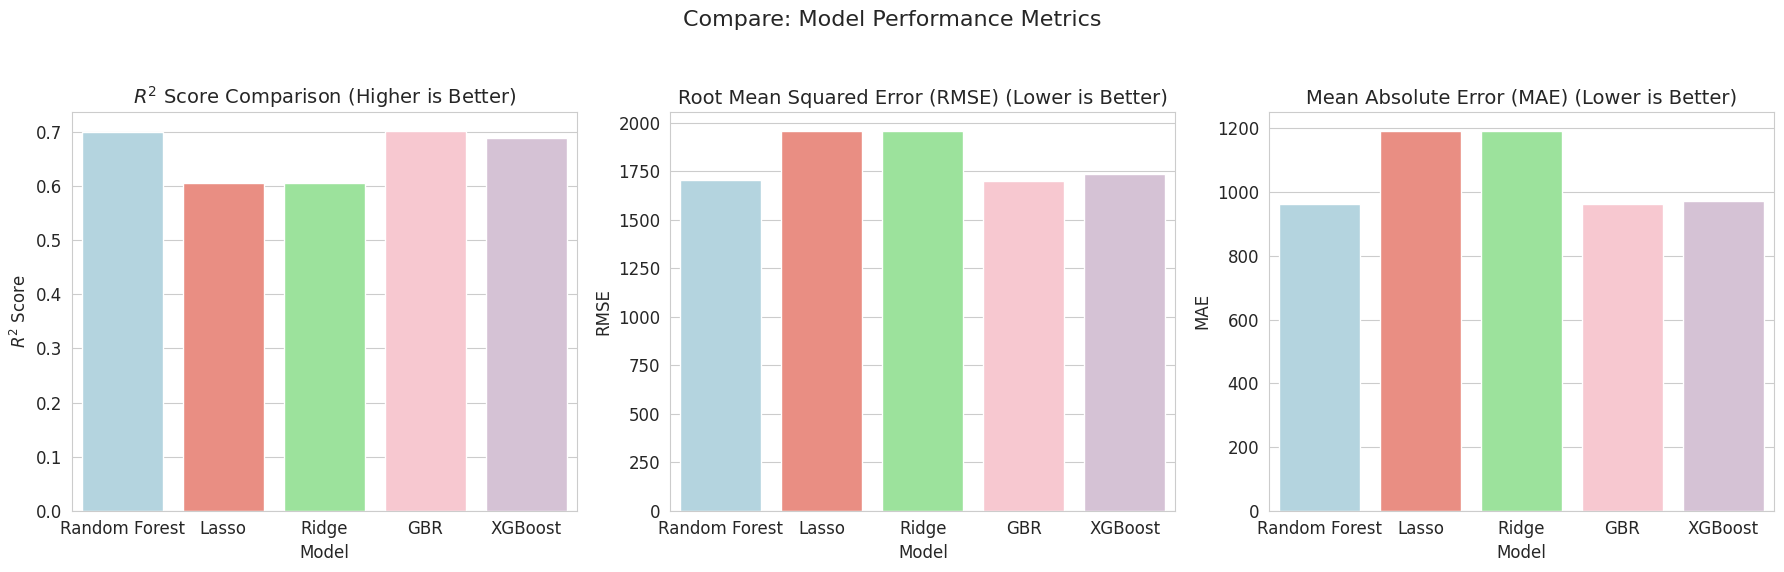

In [ ]:
# performance metrics: r2, rmse, mae
models = ['Random Forest', 'Lasso', 'Ridge', 'GBR', 'XGBoost']

r2_scores = [rf_r2, r2_lasso, r2_ridge, r2_gbr, r2_xgb]
rmse_values = [rf_rmse, rmse_lasso, rmse_ridge, rmse_gbr, rmse_xgb]
mae_values = [rf_mae, mae_lasso, mae_ridge, mae_gbr, mae_xgb]

df_metrics = pd.DataFrame({
    'Model': models,
    'R2 Score': r2_scores,
    'RMSE': rmse_values,
    'MAE': mae_values
})

model_colors = {
    'Random Forest': 'lightblue',
    'Lasso': 'salmon',
    'Ridge': 'lightgreen',
    'GBR': 'pink',
    'XGBoost': 'thistle'
}

fig, ax = plt.subplots(1, 3, figsize=(18, 6))

# R2 Score
sns.barplot(x='Model', y='R2 Score', data=df_metrics, ax=ax[0],
            palette=model_colors, hue='Model', legend=False)
ax[0].set_title('$R^2$ Score Comparison (Higher is Better)', fontsize=14)
ax[0].set_ylabel('$R^2$ Score')

# RMSE
sns.barplot(x='Model', y='RMSE', data=df_metrics, ax=ax[1],
            palette=model_colors, hue='Model', legend=False)
ax[1].set_title('Root Mean Squared Error (RMSE) (Lower is Better)', fontsize=14)
ax[1].set_ylabel('RMSE')
ax[1].ticklabel_format(style='plain', axis='y')

# MAE
sns.barplot(x='Model', y='MAE', data=df_metrics, ax=ax[2],
            palette=model_colors, hue='Model', legend=False)
ax[2].set_title('Mean Absolute Error (MAE) (Lower is Better)', fontsize=14)
ax[2].set_ylabel('MAE')
ax[2].ticklabel_format(style='plain', axis='y')


plt.suptitle('Compare: Model Performance Metrics', fontsize=16)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

Based on the visualization of comparison, it is obvious that the fittest of annual medical cost prediction is Gradient Boosting, which showes the highest R2 score and the lowest values of both RMSE and MAE.

2. Comparison between prediction and true label

Through plotting the scatter plot of the prediction label and the line chart of true test label, the accuracy and error of the model can be shown clearly.

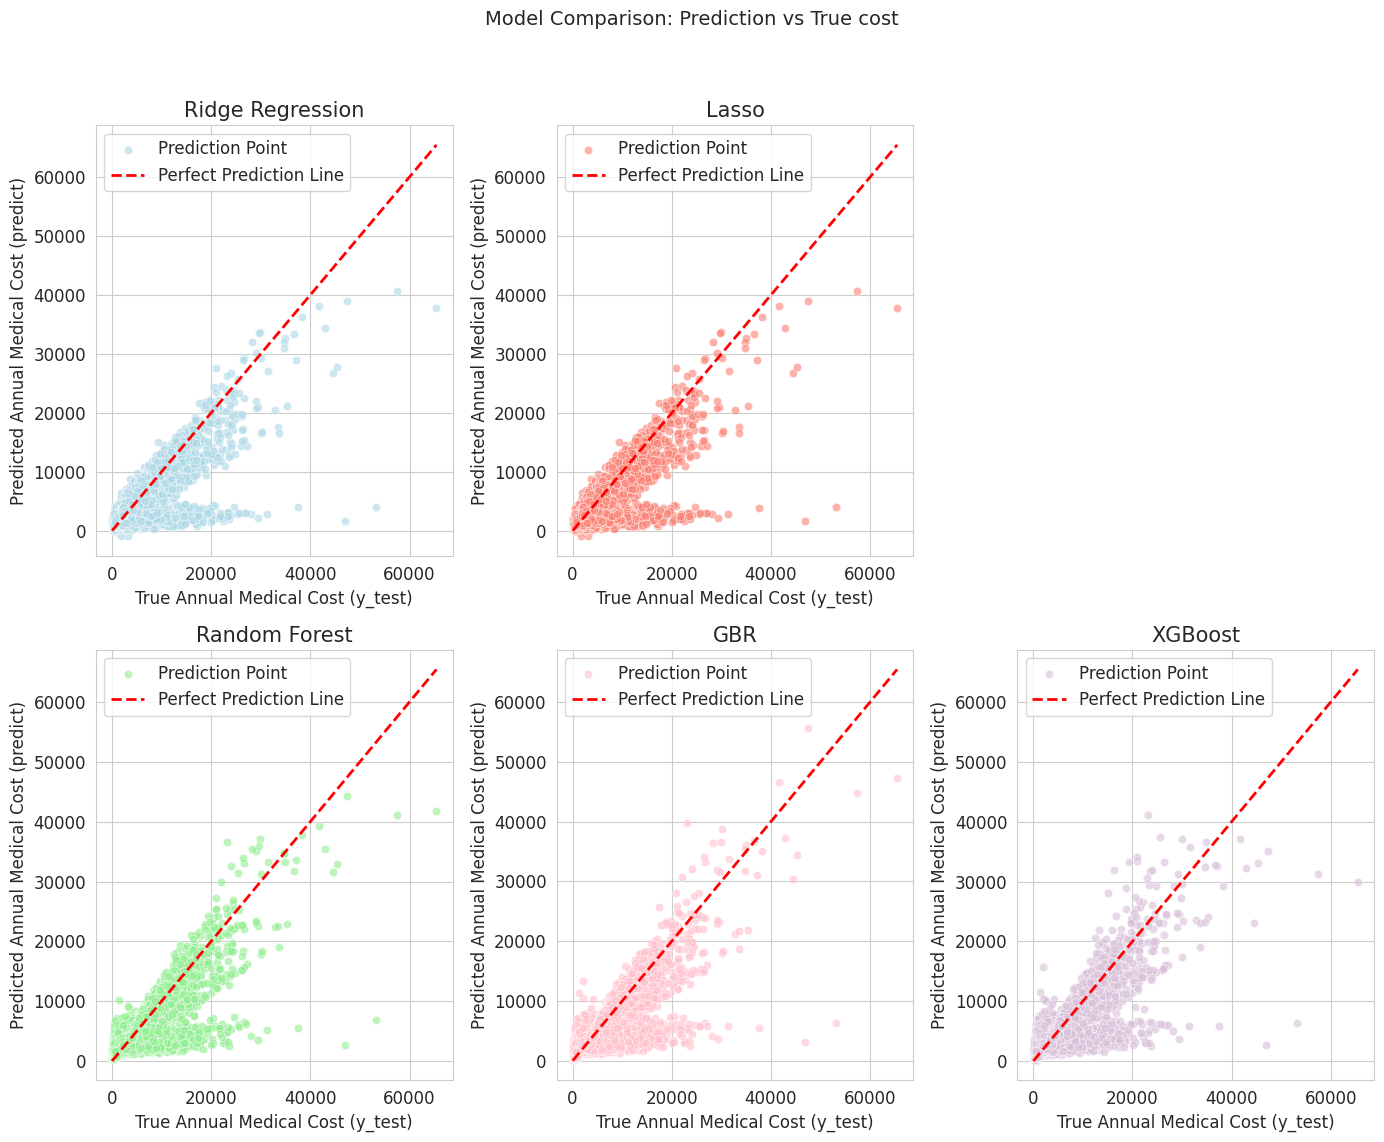

In [ ]:
sns.set_style('whitegrid')

fig, ax = plt.subplots(2, 3, figsize=(14, 12))

# Ridge Regression
# Draw a scatter plot: actual values vs. predicted values
sns.scatterplot(x=y_test, y=y_pred_ridge, ax=ax[0,0], alpha=0.6, label='Prediction Point', color='lightblue')

ax[0,0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction Line')
ax[0,0].set_title('Ridge Regression', fontsize=15)
ax[0,0].set_xlabel('True Annual Medical Cost (y_test)', fontsize=12)
ax[0,0].set_ylabel('Predicted Annual Medical Cost (predict)', fontsize=12)
ax[0,0].legend()

# Lasso Regression
# Draw a scatter plot: actual values vs. predicted values
sns.scatterplot(x=y_test, y=y_pred_lasso, ax=ax[0,1], alpha=0.6, label='Prediction Point', color='salmon')

ax[0,1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction Line')
ax[0,1].set_title('Lasso', fontsize=15)
ax[0,1].set_xlabel('True Annual Medical Cost (y_test)', fontsize=12)
ax[0,1].set_ylabel('Predicted Annual Medical Cost (predict)', fontsize=12)
ax[0,1].legend()

# Random Forest
# Draw a scatter plot: actual values vs. predicted values
sns.scatterplot(x=y_test, y=rf_predict, ax=ax[1,0], alpha=0.6, label='Prediction Point', color='lightgreen')

ax[1,0].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction Line')
ax[1,0].set_title('Random Forest', fontsize=15)
ax[1,0].set_xlabel('True Annual Medical Cost (y_test)', fontsize=12)
ax[1,0].set_ylabel('Predicted Annual Medical Cost (predict)', fontsize=12)
ax[1,0].legend()

# GBR
# Draw a scatter plot: actual values vs. predicted values
sns.scatterplot(x=y_test, y=y_pred_gbr, ax=ax[1,1], alpha=0.6, label='Prediction Point', color='pink')

ax[1,1].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction Line')
ax[1,1].set_title('GBR', fontsize=15)
ax[1,1].set_xlabel('True Annual Medical Cost (y_test)', fontsize=12)
ax[1,1].set_ylabel('Predicted Annual Medical Cost (predict)', fontsize=12)
ax[1,1].legend()

# xgboost
# Draw a scatter plot: actual values vs. predicted values
sns.scatterplot(x=y_test, y=y_pred_xgb, ax=ax[1,2], alpha=0.6, label='Prediction Point', color='thistle')

ax[1,2].plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2, label='Perfect Prediction Line')
ax[1,2].set_title('XGBoost', fontsize=15)
ax[1,2].set_xlabel('True Annual Medical Cost (y_test)', fontsize=12)
ax[1,2].set_ylabel('Predicted Annual Medical Cost (predict)', fontsize=12)
ax[1,2].legend()

ax[0,2].axis('off')

plt.suptitle('Model Comparison: Prediction vs True cost', fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

* For Random Forest:

The image confirms the same results obtained earlier through indicator analysis: the model demonstrates good accuracy for most low-cost(annual_medical_cost) data.

But produces errors for high-cost(annual_medical_cost) data.

* For both Lasso and Ridge:

These models demonstrated the poorest fit.

Their predicted points show significant deviation from the perfect prediction line (y=x), particularly failing to capture high-cost instances (True Cost>40,000).

This confirms the non-linear nature of the relationship between predictors and medical cost.

* For GBR:

Similar to Random Forest, the predicted points show an excellent overall fit, with most points distributed along the line.

However, it is better than Random Forest, because GBR can provide higher prediction rather than the average in high-cost region.


* For XGB:

Unlike Random Forest and GBR, the prediction has greater dispersion, particularly in the low-cost region, resulting in higher prediction errors.

3. Residual Plot(scatter and box plots)

$$ Residual = True Cost-Prediction $$

Diagnose the distribution and patterns of model errors.

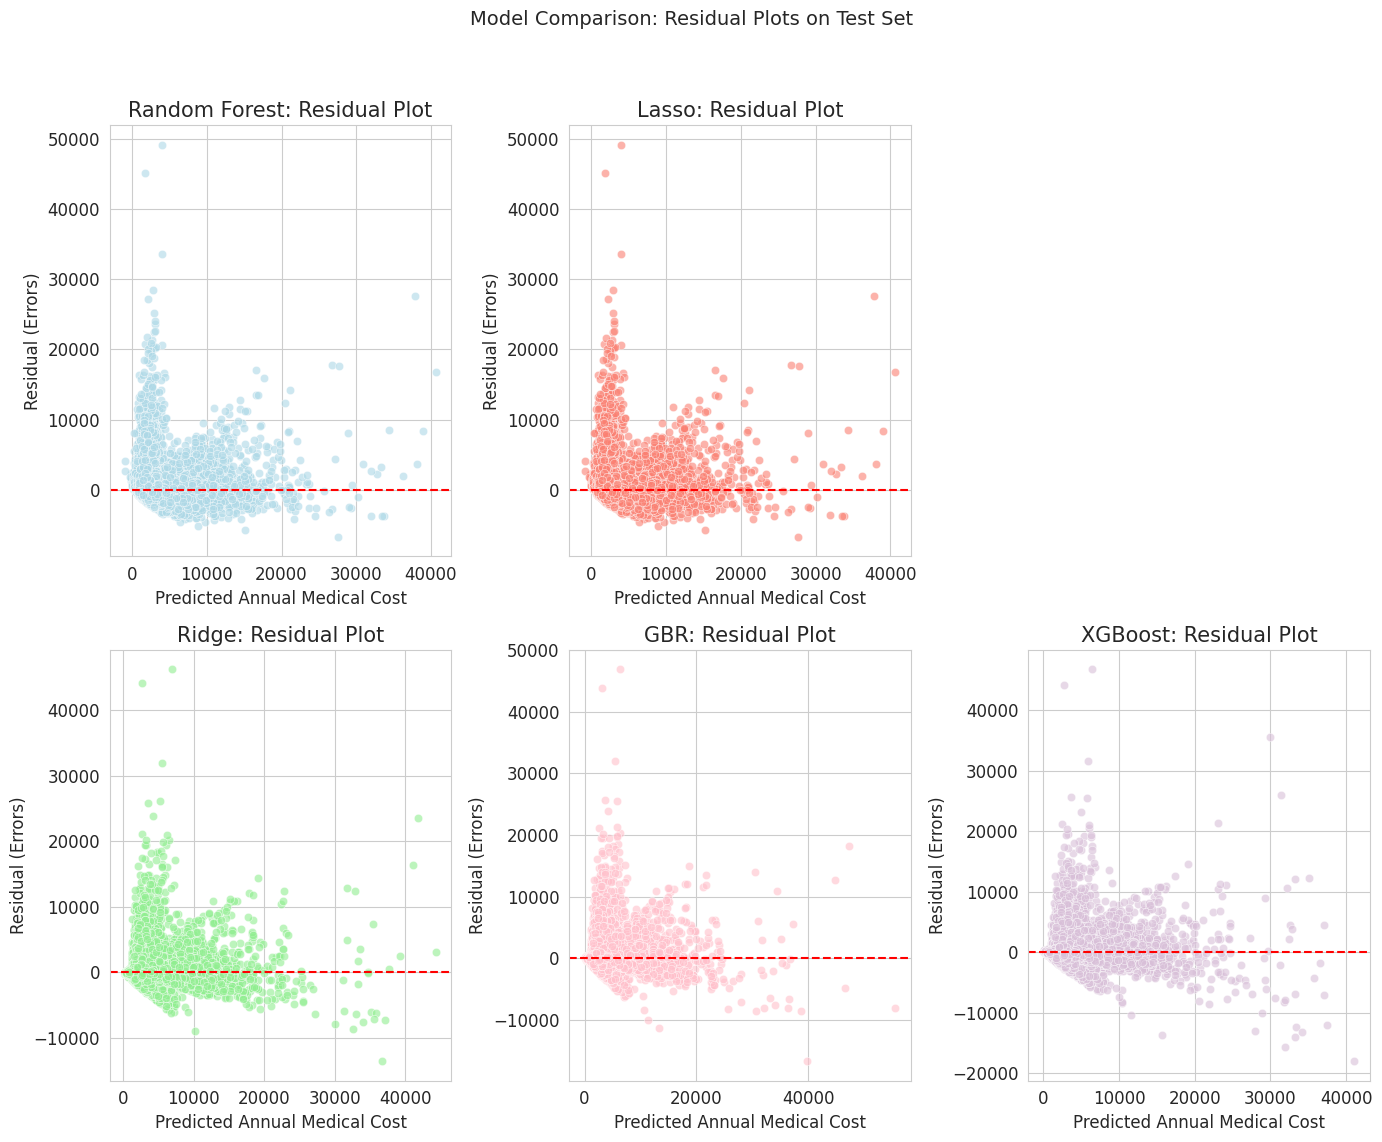

In [ ]:
# Calculate the residuals.
residuals_lasso = y_test - y_pred_lasso
residuals_ridge = y_test - y_pred_ridge
residuals_rf = y_test - rf_predict
residuals_gbr = y_test - y_pred_gbr
residuals_xgb = y_test - y_pred_xgb

fig, ax = plt.subplots(2, 3, figsize=(14, 12))

# Ridge Residual Plot
# Plotting a scatter plot: Predicted values ​​vs. Residuals
sns.scatterplot(x=y_pred_ridge, y=residuals_ridge, ax=ax[0,0], alpha=0.6, color='lightblue')

ax[0,0].axhline(y=0, color='r', linestyle='--')
ax[0,0].set_title('Random Forest: Residual Plot', fontsize=15)
ax[0,0].set_xlabel('Predicted Annual Medical Cost', fontsize=12)
ax[0,0].set_ylabel('Residual (Errors)', fontsize=12)

# Lasso Residual Plot
# Plotting a scatter plot: Predicted values ​​vs. Residuals
sns.scatterplot(x=y_pred_lasso, y=residuals_lasso, ax=ax[0,1], alpha=0.6, color='salmon')

ax[0,1].axhline(y=0, color='r', linestyle='--')
ax[0,1].set_title('Lasso: Residual Plot', fontsize=15)
ax[0,1].set_xlabel('Predicted Annual Medical Cost', fontsize=12)
ax[0,1].set_ylabel('Residual (Errors)', fontsize=12)

# Random Forest
# Plotting a scatter plot: Predicted values ​​vs. Residuals
sns.scatterplot(x=rf_predict, y=residuals_rf, ax=ax[1,0], alpha=0.6, color='lightgreen')

ax[1,0].axhline(y=0, color='r', linestyle='--')
ax[1,0].set_title('Ridge: Residual Plot', fontsize=15)
ax[1,0].set_xlabel('Predicted Annual Medical Cost', fontsize=12)
ax[1,0].set_ylabel('Residual (Errors)', fontsize=12)

# GBR
# Plotting a scatter plot: Predicted values ​​vs. Residuals
sns.scatterplot(x=y_pred_gbr, y=residuals_gbr, ax=ax[1,1], alpha=0.6, color='pink')

ax[1,1].axhline(y=0, color='r', linestyle='--')
ax[1,1].set_title('GBR: Residual Plot', fontsize=15)
ax[1,1].set_xlabel('Predicted Annual Medical Cost', fontsize=12)
ax[1,1].set_ylabel('Residual (Errors)', fontsize=12)

# XGBoost
# Plotting a scatter plot: Predicted values ​​vs. Residuals
sns.scatterplot(x=y_pred_xgb, y=residuals_xgb, ax=ax[1,2], alpha=0.6, color='thistle')

ax[1,2].axhline(y=0, color='r', linestyle='--')
ax[1,2].set_title('XGBoost: Residual Plot', fontsize=15)
ax[1,2].set_xlabel('Predicted Annual Medical Cost', fontsize=12)
ax[1,2].set_ylabel('Residual (Errors)', fontsize=12)

ax[0,2].axis('off')

plt.suptitle('Model Comparison: Residual Plots on Test Set', fontsize=14)
plt.tight_layout(rect=[0, 0.03, 1, 0.95])
plt.show()

All models fit with R2 around from 0.60 to 0.70, indicating well explanatory power.

The residual plots show slight heteroscedasticity in all models (larger prediction errors for high-cost samples).

The Gradient Boosting model has a more stable residual distribution.

/tmp/ipython-input-1964534721.py:20: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  bp = plt.boxplot(


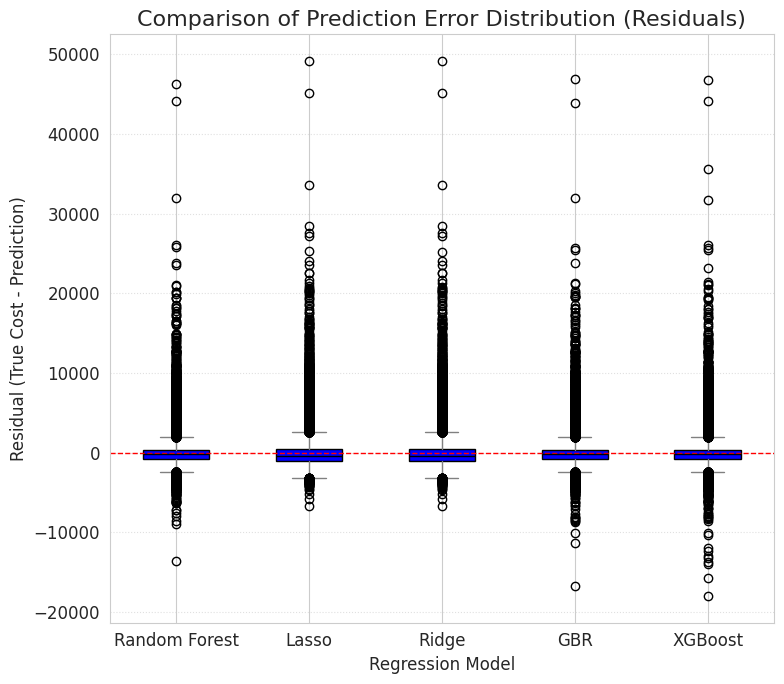

In [ ]:
data_to_plot = [
    residuals_rf,
    residuals_lasso,
    residuals_ridge,
    residuals_gbr,
    residuals_xgb
]

labels = ['Random Forest', 'Lasso', 'Ridge', 'GBR', 'XGBoost']
box_properties = {
    'patch_artist': True,
    'medianprops': {'color': 'black'},
    'whiskerprops': {'color': 'gray'},
    'capprops': {'color': 'gray'}
}

plt.figure(figsize=(8, 7))

# box plot of all models
bp = plt.boxplot(
    data_to_plot,
    labels=labels,
    vert=True,
    **box_properties
)

for patch in bp['boxes']:
    patch.set_facecolor('blue')
    patch.set_edgecolor('black')

plt.axhline(0, color='r', linestyle='--', linewidth=1)

plt.title('Comparison of Prediction Error Distribution (Residuals)', fontsize=16)
plt.xlabel('Regression Model', fontsize=12)
plt.ylabel('Residual (True Cost - Prediction)', fontsize=12)

plt.grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()
plt.show()

* GBR and Random Forest: They are the best two models for prediction task. Its box width (core error) is narrowest, and the median is perfectly centered on the zero line.

* XGBoost: Although XGBoost gets high R2 values, its box median deviates most significantly from the zero line in all five models, indicating high bias.

* Lasso and Ridge: Their box widths (core error) exceed those of GBR, but their medians remain largely centered around the zero line, indicating they are unbiased but exhibit relatively lower precision.

### Save Predict Result

In [ ]:
import os

First, save the personId and predicted labels as a new dataframe.

In [ ]:
# obtain original index of testing set
test_indices = X_test.index

# find personId using index
test_personIds = df.loc[test_indices, 'person_id']

# Random Forest
# create dataframe saving personId and predict label
rf_predict_df = pd.DataFrame({
    'person_id': test_personIds.reset_index(drop=True),
    'predict': rf_predict
})

rf_predict_df.head()

,person_id,predict
0,46195,1867.362359
1,27086,7893.172727
2,35080,3167.466964
3,15409,2762.545746
4,97759,1941.737668


In [ ]:
# lasso
# create dataframe saving personId and predict label
lasso_predict_df = pd.DataFrame({
    'person_id': test_personIds.reset_index(drop=True),
    'predict': y_pred_lasso
})

lasso_predict_df.head()

,person_id,predict
0,46195,1503.045468
1,27086,4052.397045
2,35080,3676.548967
3,15409,3545.059377
4,97759,1589.496116


In [ ]:
# ridge
# create dataframe saving personId and predict label
ridge_predict_df = pd.DataFrame({
    'person_id': test_personIds.reset_index(drop=True),
    'predict': y_pred_ridge
})

ridge_predict_df.head()

,person_id,predict
0,46195,1498.435365
1,27086,4048.006310
2,35080,3670.782186
3,15409,3556.550931
4,97759,1584.532534


In [ ]:
# GBR
# create dataframe saving personId and predict label
gbr_predict_df = pd.DataFrame({
    'person_id': test_personIds.reset_index(drop=True),
    'predict': y_pred_gbr
})

gbr_predict_df.head()

,person_id,predict
0,46195,1854.127702
1,27086,6269.593636
2,35080,3200.086996
3,15409,2854.422944
4,97759,1958.221465


In [ ]:
# XGB
# create dataframe saving personId and predict label
xgb_predict_df = pd.DataFrame({
    'person_id': test_personIds.reset_index(drop=True),
    'predict': y_pred_xgb
})

xgb_predict_df.head()

,person_id,predict
0,46195,1853.779053
1,27086,6009.597168
2,35080,3127.088135
3,15409,2838.932617
4,97759,1935.351318


Next, create a folder using to save result.

In [ ]:
folder_path = f'/content/drive/MyDrive/DSAI_5102/project/result'

# create folder
# 使用os.makedirs自动创建所有不存在的父目录
# exist_ok=True: 如果文件夹已经存在，则不报错，继续执行。
os.makedirs(folder_path, exist_ok=True)

In [ ]:
# Random Forest
rf_result_name = 'RandomForest.csv'
rf_result_path = os.path.join(folder_path, rf_result_name)

rf_predict_df.to_csv(rf_result_path, index=False)
print(f'result saved to {rf_result_path}')

# Lasso
lasso_result_name = 'Lasso.csv'
lasso_result_path = os.path.join(folder_path, lasso_result_name)

lasso_predict_df.to_csv(lasso_result_path, index=False)
print(f'result saved to {lasso_result_path}')

# ridge
ridge_result_name = 'Ridge.csv'
ridge_result_path = os.path.join(folder_path, ridge_result_name)

ridge_predict_df.to_csv(ridge_result_path, index=False)
print(f'result saved to {ridge_result_path}')

# GBR
gbr_result_name = 'GBR.csv'
gbr_result_path = os.path.join(folder_path, gbr_result_name)

gbr_predict_df.to_csv(gbr_result_path, index=False)
print(f'result saved to {gbr_result_path}')

# XGB
xgb_result_name = 'XGB.csv'
xgb_result_path = os.path.join(folder_path, xgb_result_name)

xgb_predict_df.to_csv(xgb_result_path, index=False)
print(f'result saved to {xgb_result_path}')

result saved to /content/drive/MyDrive/DSAI_5102/project/result/RandomForest.csv
result saved to /content/drive/MyDrive/DSAI_5102/project/result/Lasso.csv
result saved to /content/drive/MyDrive/DSAI_5102/project/result/Ridge.csv
result saved to /content/drive/MyDrive/DSAI_5102/project/result/GBR.csv
result saved to /content/drive/MyDrive/DSAI_5102/project/result/XGB.csv
